In [6]:
import os
import warnings
import numpy as np
import torch
import lightning.pytorch as pl
from dataclasses import dataclass
from typing import Optional, Dict
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

print("✅ Imports complete")


/home/gupt_ad/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports complete


In [165]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from numpy.lib.stride_tricks import sliding_window_view

# --- Configuration ---
DATA_FILE = '/home/gupt_ad/conclusion_work/application/ad-xai_pipeline/ATACAMA/Atacama.pkl'
WINDOW_SIZE = 60  
STEP_SIZE = 1     

FEATURE_COLUMNS = [
    'temperature_2m',       
    'relative_humidity_2m', 
    'precipitation',        
    'pressure_msl',         
    'cloud_cover',          
    'wind_speed_10m'        
]

def load_and_preprocess(filepath, window_size, step_size):
    """
    Loads Atacama data, binarizes labels, standardizes features, 
    and applies sliding window with shape correction.
    """
    print(f"Loading data from {filepath}...")
    try:
        df = pd.read_pickle(filepath)
    except FileNotFoundError:
        print(f"Error: File {filepath} not found.")
        return None, None

    # 1. Label Processing
    print("Binarizing labels...")
    label_mapping = {0: 0, 1: 1, 2: 1}
    df['binary_label'] = df['label'].map(label_mapping).fillna(0).astype(int)

    # 2. Separate Features and Targets
    available_features = [c for c in df.columns if any(f in c for f in FEATURE_COLUMNS)]
    
    if not available_features:
        print("Error: Feature columns not found. Check column names.")
        return None, None
        
    X_raw = df[available_features].values
    y_raw = df['binary_label'].values
    
    # 3. Standardization
    print("Standardizing features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # 4. Sliding Window
    print(f"Applying sliding window (Size: {window_size}, Step: {step_size})...")
    
    # --- FEATURES (X) ---
    # sliding_window_view creates shape: (N, n_features, window_size)
    X_windows_raw = sliding_window_view(X_scaled, window_shape=window_size, axis=0)[::step_size]
    
    # FIX: Move the window dimension (last axis) to the middle
    # New Shape: (N, window_size, n_features)
    X_windows = np.moveaxis(X_windows_raw, -2, -1)
    
    # --- LABELS (y) ---
    # sliding_window_view creates shape: (N, window_size)
    # This is usually correct for Sequence-to-Sequence tasks
    y_windows = sliding_window_view(y_raw, window_shape=window_size, axis=0)[::step_size]

    # NOTE: If you are doing Sequence-to-One (predicting only the next step), 
    # uncomment the line below to take only the last label of the window:
    # y_windows = y_windows[:, -1]

    print(f"Processing complete.")
    print(f"X shape: {X_windows.shape}") # (N_windows, 60, 6)
    print(f"y shape: {y_windows.shape}") # (N_windows, 60)
    
    return X_windows, y_windows

if __name__ == "__main__":
    X, y = load_and_preprocess(DATA_FILE, WINDOW_SIZE, STEP_SIZE)
    
    if X is not None:
        print("Data ready for model input.")
        # Verification
        # X: (Batch, Time, Features)
        # y: (Batch, Time)

Loading data from /home/gupt_ad/conclusion_work/application/ad-xai_pipeline/ATACAMA/Atacama.pkl...
Binarizing labels...
Standardizing features...
Applying sliding window (Size: 60, Step: 1)...
Processing complete.
X shape: (219109, 60, 6)
y shape: (219109, 60)
Data ready for model input.


In [166]:
X.shape, y.shape

((219109, 60, 6), (219109, 60))

In [149]:
# X = X.transpose(0, 2, 1)
# X.shape

(219109, 60, 6)

In [159]:
# Your X should be: (N_windows, window_size, n_features)
# Your y should be: (N_windows, window_size) with binary labels

def prepare_labels(y_windows):
    """Label window as anomaly if ANY timestep is anomalous"""
    if y_windows.ndim == 2:
        return (y_windows.sum(axis=1) > 0).astype(np.int64)
    elif y_windows.ndim == 1:
        return y_windows.astype(np.int64)
    else:
        raise ValueError(f"Unexpected y shape: {y_windows.shape}")

# Convert labels
y_labels = prepare_labels(y)
X = X_fixed.astype(np.float32)

print(f"✅ Data prepared:")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y_labels.shape}")
print(f"   Normal windows: {(y_labels == 0).sum()} ({(y_labels == 0).mean():.1%})")
print(f"   Anomaly windows: {(y_labels == 1).sum()} ({(y_labels == 1).mean():.1%})")


✅ Data prepared:
   X shape: (219109, 6, 60)
   y shape: (219109,)
   Normal windows: 218331 (99.6%)
   Anomaly windows: 778 (0.4%)


In [168]:
from torch.utils.data import Dataset, DataLoader

@dataclass
class AnomalyConfig:
    batch_size: int = 512
    max_epochs: int = 15
    patience: int = 10
    seed: int = 42
    num_workers: int = 16
    input_size: int = 6
    hidden_size: int = 128
    num_layers: int = 2
    dropout: float = 0.2
    lr: float = 1e-3
    weight_decay: float = 1e-4
    train_normals_only: bool = True
    use_amp: bool = True
    ckpt_dir: str = "atacama_checkpoints"
    log_dir: str = "atacama_logs"

class WindowDataset(Dataset):
    def __init__(self, windows, labels=None):
        self.x = torch.tensor(windows, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32) if labels is not None else None
    
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        return self.x[idx], (self.y[idx] if self.y is not None else None)

print("✅ Config classes defined")


✅ Config classes defined


In [169]:
import torch.nn as nn
import torch.nn.functional as F

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.proj = nn.Linear(hidden_size, input_size)
    
    def forward(self, x):
        B, L, _ = x.shape
        _, (h_n, c_n) = self.encoder(x)
        z = h_n[-1]
        dec_in = z.unsqueeze(1).repeat(1, L, 1)
        dec_out, _ = self.decoder(dec_in, (h_n, c_n))
        return self.proj(dec_out)

print("✅ Model architecture defined")


✅ Model architecture defined


In [170]:
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, RichProgressBar, TQDMProgressBar
from lightning.pytorch.loggers import CSVLogger
from sklearn.metrics import precision_recall_curve

class ReconstructionAnomalyModule(pl.LightningModule):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.save_hyperparameters()
        self.model = LSTMAutoencoder(cfg.input_size, cfg.hidden_size, cfg.num_layers, cfg.dropout)
        self.register_buffer("optimal_thresh", torch.tensor(0.0))
        self.register_buffer("best_val_f1", torch.tensor(0.0))
        self._val_scores = []
        self._val_targets = []
    
    @staticmethod
    def _window_mse(x, x_hat):
        return ((x - x_hat) ** 2).mean(dim=(1, 2))
    
    def forward(self, x):
        return self.model(x)
    
    def training_step(self, batch, batch_idx):
        x, _ = batch
        x_hat = self(x)
        loss = F.mse_loss(x_hat, x)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        x_hat = self(x)
        loss = F.mse_loss(x_hat, x)
        scores = self._window_mse(x, x_hat).detach()
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        if y is not None:
            self._val_scores.append(scores.cpu())
            self._val_targets.append(y.detach().cpu())
    
    def on_validation_epoch_end(self):
        if len(self._val_scores) == 0:
            return
        scores = torch.cat(self._val_scores).numpy()
        targets = torch.cat(self._val_targets).numpy().astype(int)
        precision, recall, thresholds = precision_recall_curve(targets, scores)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)
        if thresholds.size > 0:
            best_idx = int(np.nanargmax(f1[:-1]))
            best_thresh, best_f1 = float(thresholds[best_idx]), float(f1[best_idx])
            if best_f1 > float(self.best_val_f1.item()):
                self.best_val_f1.fill_(best_f1)
                self.optimal_thresh.fill_(best_thresh)
            self.log("val/best_f1", best_f1, prog_bar=True)
        self._val_scores.clear()
        self._val_targets.clear()
    
    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.cfg.lr, weight_decay=self.cfg.weight_decay)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sch, "monitor": "val_loss", "interval": "epoch"}}

print("✅ Lightning module defined")


✅ Lightning module defined


In [172]:
def find_split_with_anomalies(labels, train_ratio=0.7, val_ratio=0.15):
    """Find split points that ensure anomalies in all sets"""
    N = len(labels)
    anomaly_indices = np.where(labels == 1)[0]
    
    print(f"📊 Total anomalies: {len(anomaly_indices)}")
    print(f"   First anomaly at index: {anomaly_indices[0]}")
    print(f"   Last anomaly at index: {anomaly_indices[-1]}")
    
    # Adjust splits to include anomalies
    min_anomalies_per_split = 10  # Minimum anomalies we want per split
    
    # Start from first anomaly
    first_anom = anomaly_indices[0]
    last_anom = anomaly_indices[-1]
    
    # Calculate split points
    available_range = last_anom - first_anom
    train_end = first_anom + int(available_range * (train_ratio / (train_ratio + val_ratio + (1 - train_ratio - val_ratio))))
    val_end = first_anom + int(available_range * ((train_ratio + val_ratio) / (train_ratio + val_ratio + (1 - train_ratio - val_ratio))))
    
    # Verify each split has anomalies
    train_anoms = np.sum((anomaly_indices >= 0) & (anomaly_indices < train_end))
    val_anoms = np.sum((anomaly_indices >= train_end) & (anomaly_indices < val_end))
    test_anoms = np.sum(anomaly_indices >= val_end)
    
    print(f"\n   Train: 0 to {train_end} ({train_anoms} anomalies)")
    print(f"   Val: {train_end} to {val_end} ({val_anoms} anomalies)")
    print(f"   Test: {val_end} to {N} ({test_anoms} anomalies)")
    
    return slice(0, train_end), slice(train_end, val_end), slice(val_end, N)

def create_dataloaders_smart_split(cfg, windows, labels):
    tr, va, te = find_split_with_anomalies(labels)
    
    if cfg.train_normals_only:
        train_mask = labels[tr] == 0
        train_ds = WindowDataset(windows[tr][train_mask], labels[tr][train_mask])
    else:
        train_ds = WindowDataset(windows[tr], labels[tr])
    
    val_ds = WindowDataset(windows[va], labels[va])
    test_ds = WindowDataset(windows[te], labels[te])
    
    pin = torch.cuda.is_available()
    return {
        "train": DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, 
                           num_workers=cfg.num_workers, pin_memory=pin),
        "val": DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, 
                         num_workers=cfg.num_workers, pin_memory=pin),
        "test": DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, 
                          num_workers=cfg.num_workers, pin_memory=pin),
    }

class DetailedProgressBar(TQDMProgressBar):
    def init_train_tqdm(self):
        bar = super().init_train_tqdm()
        bar.set_description(f'Epoch {self.trainer.current_epoch}/{self.trainer.max_epochs}')
        return bar
    
    def on_train_epoch_start(self, trainer, pl_module):
        super().on_train_epoch_start(trainer, pl_module)
        if self.main_progress_bar is not None:
            self.main_progress_bar.set_description(
                f'Epoch {trainer.current_epoch + 1}/{trainer.max_epochs}'
            )


            

# Use this version instead
loaders = create_dataloaders_smart_split(cfg, X, y_labels)

n_features = X.shape[2]
cfg = AnomalyConfig(input_size=n_features)

print("🚀 Training model...")
print(f"   Features: {n_features}, Window: {X.shape[1]}, GPU: {torch.cuda.is_available()}")


pl.seed_everything(cfg.seed, workers=True)
model_module = ReconstructionAnomalyModule(cfg)

os.makedirs(cfg.ckpt_dir, exist_ok=True)
callbacks = [
    EarlyStopping(monitor="val_loss", patience=cfg.patience, mode="min"),
    ModelCheckpoint(dirpath=cfg.ckpt_dir, monitor="val_loss", mode="min", save_top_k=1, save_last=True),
    TQDMProgressBar(refresh_rate=1, leave=True),  # leave=True keeps bars after each epoch
]

trainer = pl.Trainer(
    max_epochs=cfg.max_epochs, callbacks=callbacks, logger=CSVLogger(cfg.log_dir),
    accelerator="gpu" if torch.cuda.is_available() else "cpu", devices="auto",
    precision="16-mixed" if (cfg.use_amp and torch.cuda.is_available()) else 32, deterministic=True,
)

trainer.fit(model_module, loaders["train"], loaders["val"])
print("✅ Training complete!")


📊 Total anomalies: 778
   First anomaly at index: 3621
   Last anomaly at index: 202506

   Train: 0 to 142840 (435 anomalies)
   Val: 142840 to 172673 (70 anomalies)
   Test: 172673 to 219109 (273 anomalies)


[rank: 0] Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)


🚀 Training model...
   Features: 6, Window: 60, GPU: True


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ LSTMAutoencoder │  466 K │ train │     0 │
└───┴───────┴─────────────────┴────────┴───────┴───────┘

Trainable params: 466 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 466 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training: |                                                               | 0/? [00:00<?, ?it/s]
Epoch 0: 100%|██████████████████████████████████████| 279/279 [00:06<00:00, 46.04it/s, v_num=13]
Validation: |                                                             | 0/? [00:00<?, ?it/s]
Validation: |                                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████████████████████████████| 59/59 [00:00<00:00, 93.71it/s]
Epoch 0: 100%|█| 279/279 [00:08<00:00, 33.98it/s, v_num=13, val_loss=0.384, val/best_f1=0.912, t
Epoch 1: 100%|█| 279/279 [00:07<00:00, 37.91it/s, v_num=13, val_loss=0.384, val/best_f1=0.912, t
Validation: |                                                             | 0/? [00:00<?, ?it/s]
Validation: |                                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████████████████████████████| 59/59 [00:00<00:00, 93.28it/s]
Epoch 1: 100%|█| 279/279 [00:0

`Trainer.fit` stopped: `max_epochs=15` reached.



✅ Training complete!


In [173]:
# Quick check of current training progress
log_path = os.path.join(cfg.log_dir, "lightning_logs/version_13/metrics.csv")
logs_df = pd.read_csv(log_path)

# Get latest metrics
latest_metrics = logs_df.dropna(subset=['val/best_f1']).tail(5)

print("📊 Latest Training Metrics (last 5 epochs with F1):")
print(latest_metrics[['epoch', 'train_loss', 'val_loss', 'val/best_f1']])

if len(latest_metrics) > 0:
    best_f1 = logs_df['val/best_f1'].max()
    print(f"\n✅ Best F1 so far: {best_f1:.4f}")
else:
    print("\n⏳ F1 scores not yet logged (training just started)")


📊 Latest Training Metrics (last 5 epochs with F1):
    epoch  train_loss  val_loss  val/best_f1
20     10         NaN  0.214487     0.649123
22     11         NaN  0.222541     0.546256
24     12         NaN  0.204119     0.701493
26     13         NaN  0.209349     0.671875
28     14         NaN  0.215468     0.631579

✅ Best F1 so far: 0.9231


Available columns in logs:
['epoch', 'step', 'train_loss', 'val/best_f1', 'val_loss']


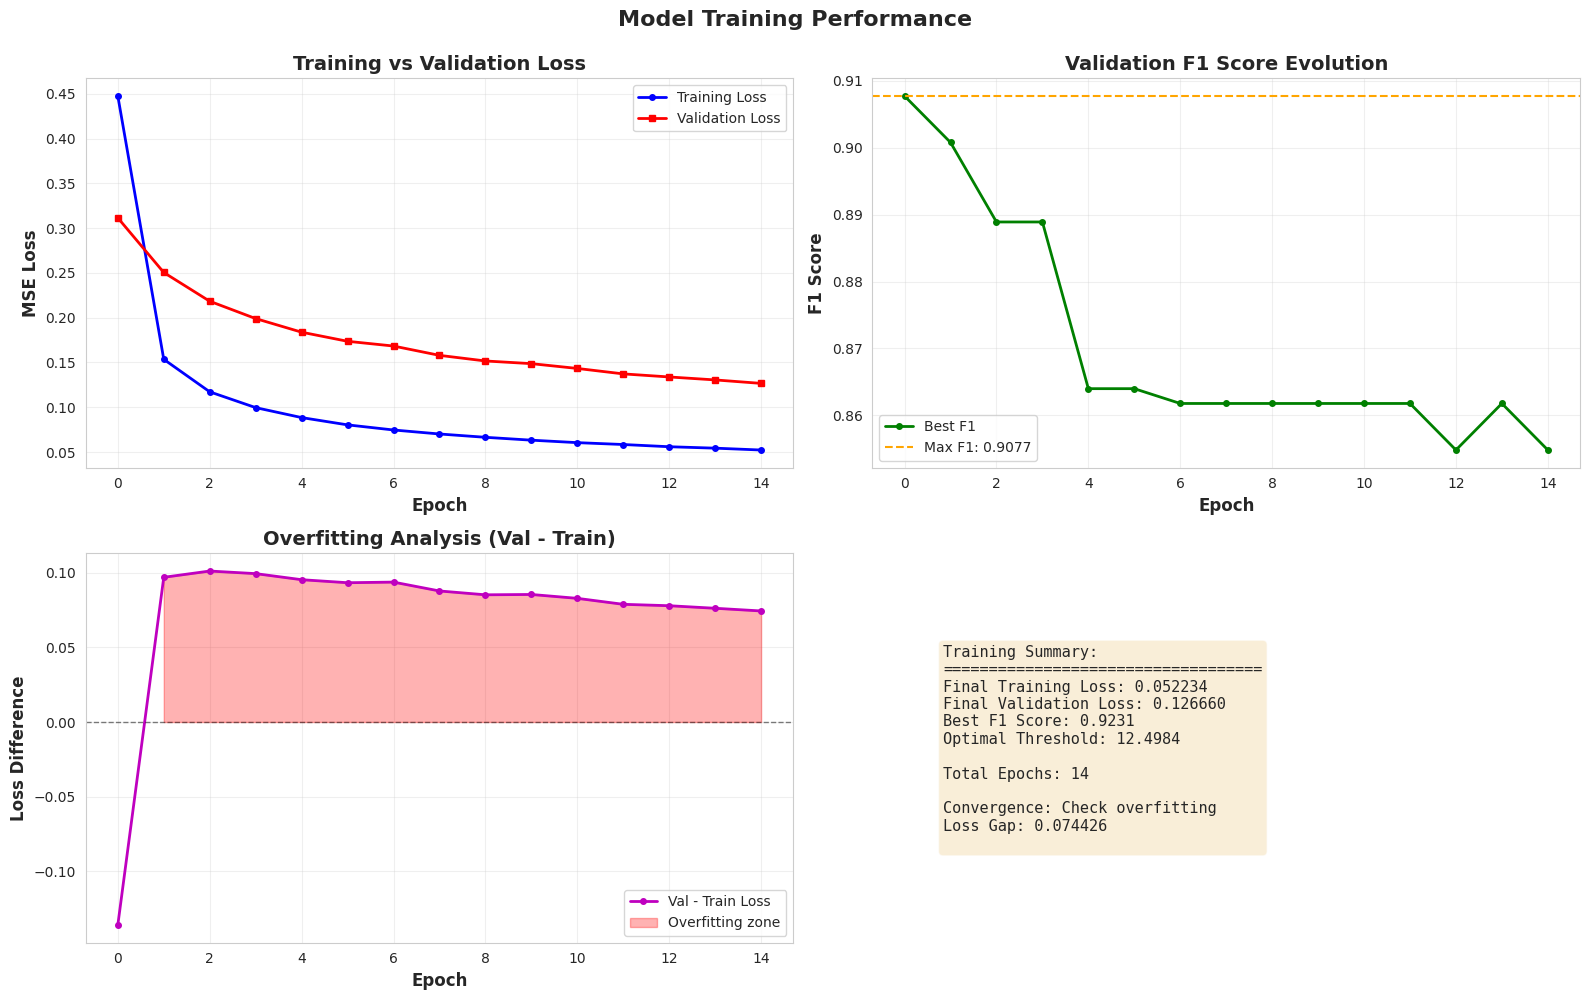

✅ Training history visualized
📊 Model achieved F1=0.9231 with threshold=12.4984


In [174]:
# ============================================================
# CELL 6.1: Load Training Logs and Visualize Training History (FIXED)
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Load CSV logs
log_path = os.path.join(cfg.log_dir, "lightning_logs/version_5/metrics.csv")
logs_df = pd.read_csv(log_path)
logs_df = logs_df.dropna(subset=['epoch'])

print("Available columns in logs:")
print(logs_df.columns.tolist())

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Training and Validation Loss
ax1 = axes[0, 0]
train_loss = logs_df[['epoch', 'train_loss']].dropna()
val_loss = logs_df[['epoch', 'val_loss']].dropna()

ax1.plot(train_loss['epoch'], train_loss['train_loss'], 
         'b-o', label='Training Loss', linewidth=2, markersize=4)
ax1.plot(val_loss['epoch'], val_loss['val_loss'], 
         'r-s', label='Validation Loss', linewidth=2, markersize=4)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('MSE Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Validation F1 Score
ax2 = axes[0, 1]
if 'val/best_f1' in logs_df.columns:
    val_f1 = logs_df[['epoch', 'val/best_f1']].dropna()
    if len(val_f1) > 0:
        ax2.plot(val_f1['epoch'], val_f1['val/best_f1'], 
                 'g-o', label='Best F1', linewidth=2, markersize=4)
        max_f1 = val_f1['val/best_f1'].max()
        ax2.axhline(y=max_f1, color='orange', linestyle='--', 
                    label=f'Max F1: {max_f1:.4f}')
        ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        ax2.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
        ax2.set_title('Validation F1 Score Evolution', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'F1 Score Not Logged', ha='center', va='center', 
             fontsize=14, transform=ax2.transAxes)
    ax2.axis('off')

# Plot 3: Loss Difference (Overfitting Check)
ax3 = axes[1, 0]
# Merge train and val loss on epoch
merged = train_loss.merge(val_loss, on='epoch', how='inner')
if len(merged) > 0:
    loss_diff = merged['val_loss'] - merged['train_loss']
    ax3.plot(merged['epoch'], loss_diff, 'm-o', label='Val - Train Loss', linewidth=2, markersize=4)
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax3.fill_between(merged['epoch'], 0, loss_diff, where=(loss_diff > 0), 
                     alpha=0.3, color='red', label='Overfitting zone')
    ax3.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Loss Difference', fontsize=12, fontweight='bold')
    ax3.set_title('Overfitting Analysis (Val - Train)', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Insufficient Data', ha='center', va='center', 
             fontsize=14, transform=ax3.transAxes)
    ax3.axis('off')

# Plot 4: Training Summary
ax4 = axes[1, 1]
final_train_loss = train_loss["train_loss"].iloc[-1]
final_val_loss = val_loss["val_loss"].iloc[-1]
total_epochs = int(logs_df["epoch"].max())

# Get final F1 and threshold from model directly (not from logs)
final_f1 = float(model_module.best_val_f1.item())
final_threshold = float(model_module.optimal_thresh.item())

convergence_status = 'Good' if final_val_loss < final_train_loss * 1.5 else 'Check overfitting'

summary_text = f'''Training Summary:
{'='*35}
Final Training Loss: {final_train_loss:.6f}
Final Validation Loss: {final_val_loss:.6f}
Best F1 Score: {final_f1:.4f}
Optimal Threshold: {final_threshold:.4f}

Total Epochs: {total_epochs}

Convergence: {convergence_status}
Loss Gap: {abs(final_val_loss - final_train_loss):.6f}
'''
ax4.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax4.axis('off')

plt.suptitle('Model Training Performance', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✅ Training history visualized")
print(f"📊 Model achieved F1={final_f1:.4f} with threshold={final_threshold:.4f}")


In [175]:
# ============================================================
# CELL 6.2: Evaluate Model on Test Set (FIXED)
# ============================================================
import torch # Ensure torch is imported
import numpy as np

print("🧪 Evaluating model on test set...")

# Get test predictions directly (skip trainer.test since no test_step defined)
model_module.eval()

# --- FIX START: Define 'device' based on the model's location ---
# This ensures x matches the model, whether it's on CPU or CUDA
try:
    # Works for PyTorch Lightning modules
    device = model_module.device
except AttributeError:
    # Universal fallback for standard PyTorch modules
    device = next(model_module.parameters()).device
# --- FIX END ---

test_loader = loaders["test"]

all_scores = []
all_labels = []
all_reconstructions = []

print(f"Computing predictions on test set (using {device})...")
with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        x, y = batch
        x = x.to(device) # Now 'device' is defined
        x_hat = model_module(x)
        
        # Compute reconstruction scores
        scores = model_module._window_mse(x, x_hat).cpu().numpy()
        all_scores.extend(scores)
        
        if y is not None:
            all_labels.extend(y.cpu().numpy())
        
        # Show progress
        if (batch_idx + 1) % 10 == 0:
            print(f"  Processed {(batch_idx + 1) * cfg.batch_size} samples...")

all_scores = np.array(all_scores)
all_labels = np.array(all_labels).astype(int)

# Apply threshold
threshold_val = model_module.optimal_thresh.item()
all_preds = (all_scores >= threshold_val).astype(int)

print(f"\n✅ Test set evaluation complete")
print(f"   Total test samples: {len(all_scores)}")
print(f"   Threshold: {threshold_val:.4f}")
print(f"   Normal samples: {(all_labels == 0).sum()}")
print(f"   Anomaly samples: {(all_labels == 1).sum()}")

🧪 Evaluating model on test set...
Computing predictions on test set (using cpu)...
  Processed 5120 samples...
  Processed 10240 samples...
  Processed 15360 samples...
  Processed 20480 samples...
  Processed 25600 samples...
  Processed 30720 samples...
  Processed 35840 samples...
  Processed 40960 samples...
  Processed 46080 samples...

✅ Test set evaluation complete
   Total test samples: 46436
   Threshold: 12.4984
   Normal samples: 46163
   Anomaly samples: 273


In [176]:
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

# Calculate metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("=" * 60)
print("📊 TEST SET PERFORMANCE METRICS")
print("=" * 60)
print(f"\nConfusion Matrix:")
print(f"   True Negatives:  {tn:6d}")
print(f"   False Positives: {fp:6d}")
print(f"   False Negatives: {fn:6d}")
print(f"   True Positives:  {tp:6d}")
print(f"\nClassification Metrics:")
print(f"   Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision:   {precision:.4f}")
print(f"   Recall:      {recall:.4f}")
print(f"   F1-Score:    {f1:.4f}")
print(f"   Specificity: {specificity:.4f}")
print("=" * 60)

# Detailed classification report
print("\n📋 Detailed Classification Report:")
print(classification_report(all_labels, all_preds, 
                          target_names=['Normal', 'Anomaly'], digits=4))


📊 TEST SET PERFORMANCE METRICS

Confusion Matrix:
   True Negatives:   46163
   False Positives:      0
   False Negatives:    270
   True Positives:       3

Classification Metrics:
   Accuracy:    0.9942 (99.42%)
   Precision:   1.0000
   Recall:      0.0110
   F1-Score:    0.0217
   Specificity: 1.0000

📋 Detailed Classification Report:
              precision    recall  f1-score   support

      Normal     0.9942    1.0000    0.9971     46163
     Anomaly     1.0000    0.0110    0.0217       273

    accuracy                         0.9942     46436
   macro avg     0.9971    0.5055    0.5094     46436
weighted avg     0.9942    0.9942    0.9913     46436



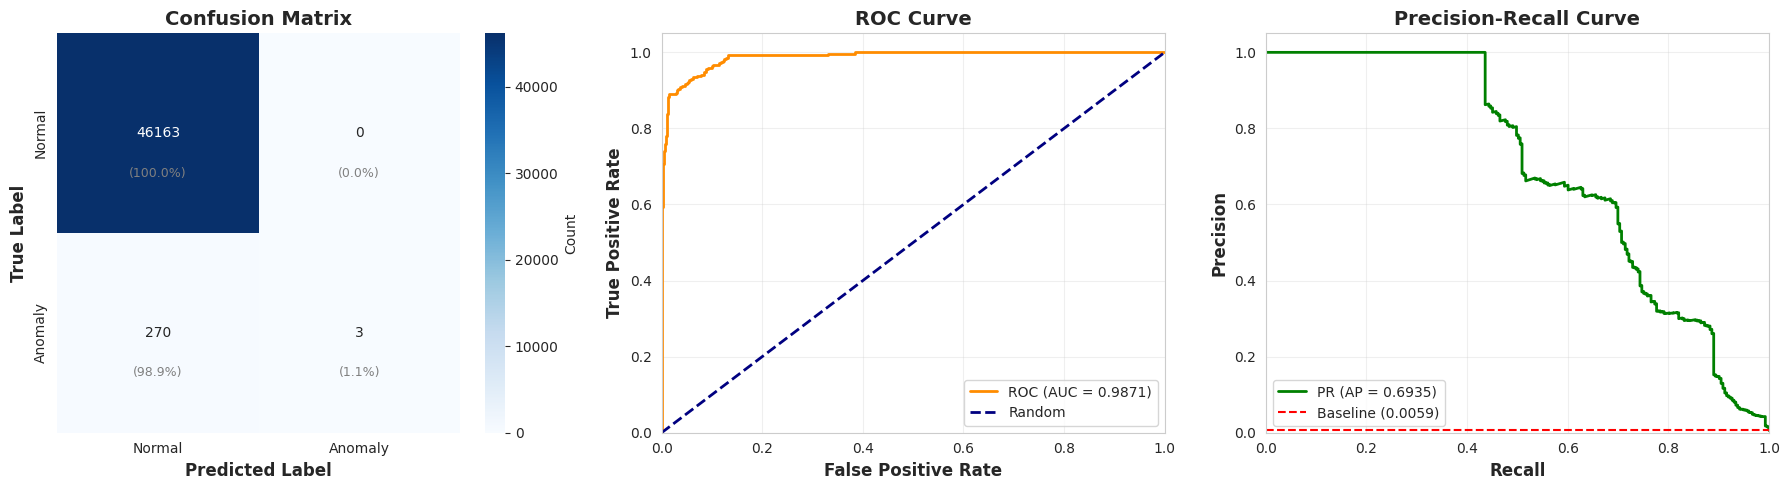

✅ Performance curves visualized


In [177]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion Matrix
ax1 = axes[0]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax1.set_xticklabels(['Normal', 'Anomaly'])
ax1.set_yticklabels(['Normal', 'Anomaly'])

# Add percentages
for i in range(2):
    for j in range(2):
        percentage = cm_normalized[i, j] * 100
        ax1.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=9, color='gray')

# Plot 2: ROC Curve
ax2 = axes[1]
fpr, tpr, _ = roc_curve(all_labels, all_scores)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(loc="lower right", fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Precision-Recall Curve
ax3 = axes[2]
precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_scores)
avg_precision = average_precision_score(all_labels, all_scores)

ax3.plot(recall_curve, precision_curve, color='green', lw=2,
         label=f'PR (AP = {avg_precision:.4f})')
ax3.axhline(y=all_labels.mean(), color='red', linestyle='--', 
            label=f'Baseline ({all_labels.mean():.4f})')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax3.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax3.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax3.legend(loc="lower left", fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Performance curves visualized")


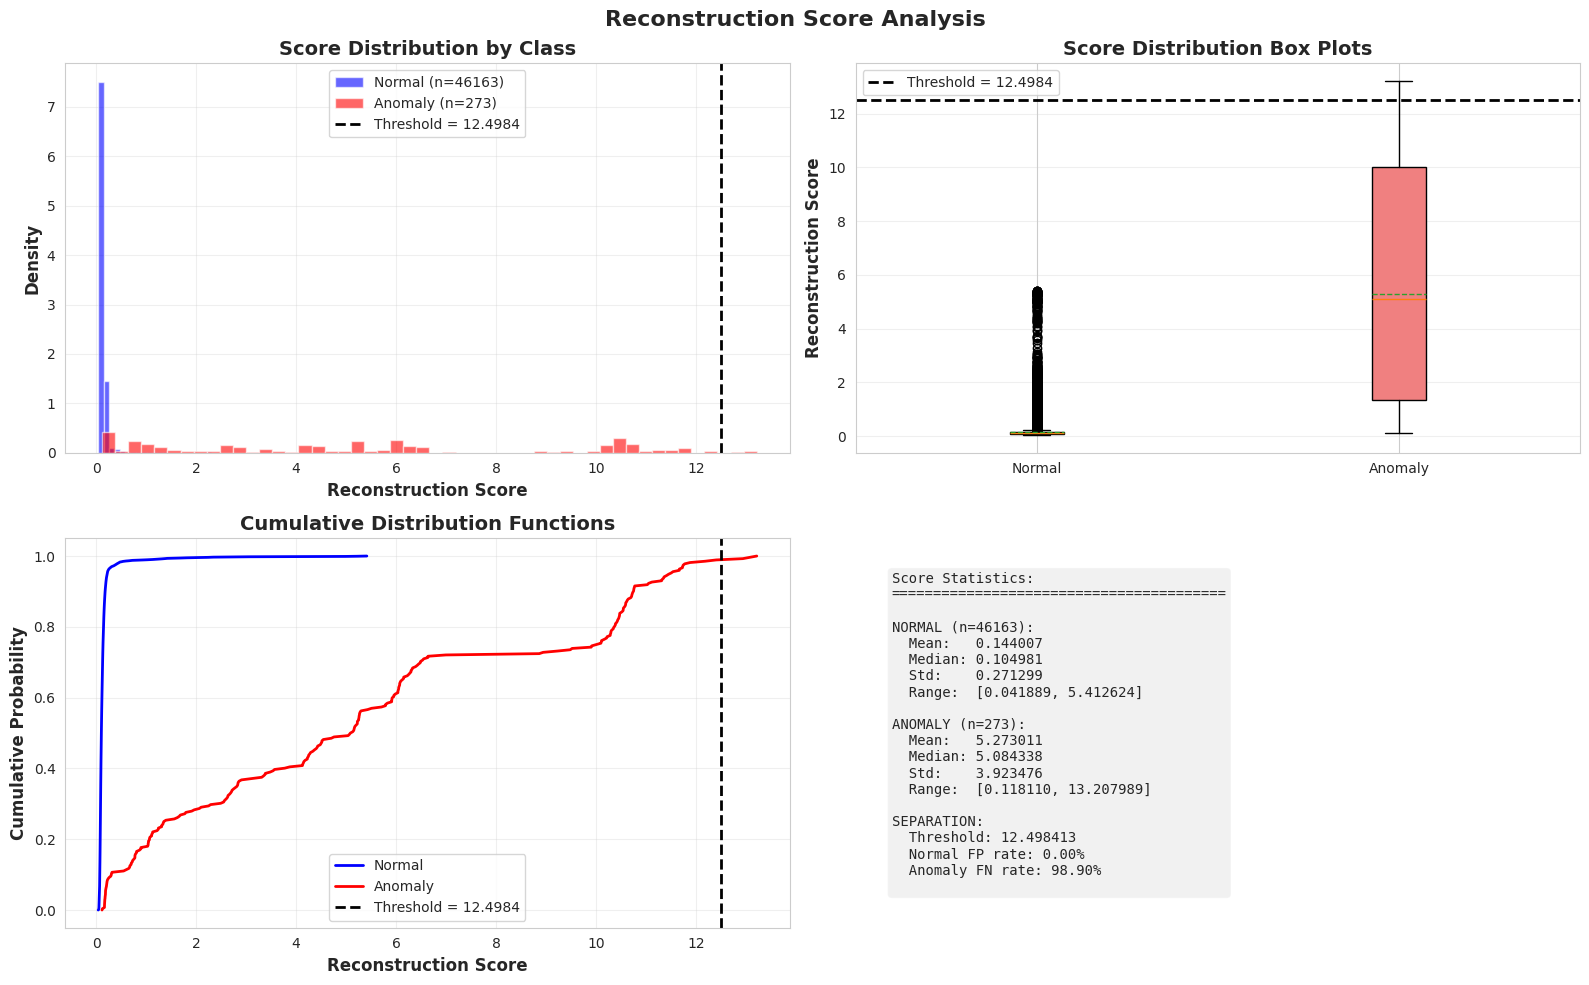

✅ Score distribution analysis complete


In [178]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Get scores by class
normal_scores = all_scores[all_labels == 0]
anomaly_scores = all_scores[all_labels == 1]

# Plot 1: Histogram
ax1 = axes[0, 0]
ax1.hist(normal_scores, bins=50, alpha=0.6, color='blue', 
         label=f'Normal (n={len(normal_scores)})', density=True)
ax1.hist(anomaly_scores, bins=50, alpha=0.6, color='red', 
         label=f'Anomaly (n={len(anomaly_scores)})', density=True)
ax1.axvline(threshold_val, color='black', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold_val:.4f}')
ax1.set_xlabel('Reconstruction Score', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Score Distribution by Class', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Box Plot
ax2 = axes[0, 1]
box_data = [normal_scores, anomaly_scores]
bp = ax2.boxplot(box_data, labels=['Normal', 'Anomaly'], patch_artist=True,
                 showmeans=True, meanline=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
ax2.axhline(threshold_val, color='black', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold_val:.4f}')
ax2.set_ylabel('Reconstruction Score', fontsize=12, fontweight='bold')
ax2.set_title('Score Distribution Box Plots', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Cumulative Distribution
ax3 = axes[1, 0]
sorted_normal = np.sort(normal_scores)
sorted_anomaly = np.sort(anomaly_scores)
ax3.plot(sorted_normal, np.linspace(0, 1, len(sorted_normal)), 
         'b-', label='Normal', linewidth=2)
ax3.plot(sorted_anomaly, np.linspace(0, 1, len(sorted_anomaly)), 
         'r-', label='Anomaly', linewidth=2)
ax3.axvline(threshold_val, color='black', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold_val:.4f}')
ax3.set_xlabel('Reconstruction Score', fontsize=12, fontweight='bold')
ax3.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax3.set_title('Cumulative Distribution Functions', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot 4: Statistics
ax4 = axes[1, 1]
stats_text = f'''Score Statistics:
{'='*40}

NORMAL (n={len(normal_scores)}):
  Mean:   {normal_scores.mean():.6f}
  Median: {np.median(normal_scores):.6f}
  Std:    {normal_scores.std():.6f}
  Range:  [{normal_scores.min():.6f}, {normal_scores.max():.6f}]

ANOMALY (n={len(anomaly_scores)}):
  Mean:   {anomaly_scores.mean():.6f}
  Median: {np.median(anomaly_scores):.6f}
  Std:    {anomaly_scores.std():.6f}
  Range:  [{anomaly_scores.min():.6f}, {anomaly_scores.max():.6f}]

SEPARATION:
  Threshold: {threshold_val:.6f}
  Normal FP rate: {(normal_scores >= threshold_val).mean()*100:.2f}%
  Anomaly FN rate: {(anomaly_scores < threshold_val).mean()*100:.2f}%
'''
ax4.text(0.05, 0.5, stats_text, fontsize=10, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.3))
ax4.axis('off')

plt.suptitle('Reconstruction Score Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Score distribution analysis complete")


🎨 Visualizing sample reconstructions...


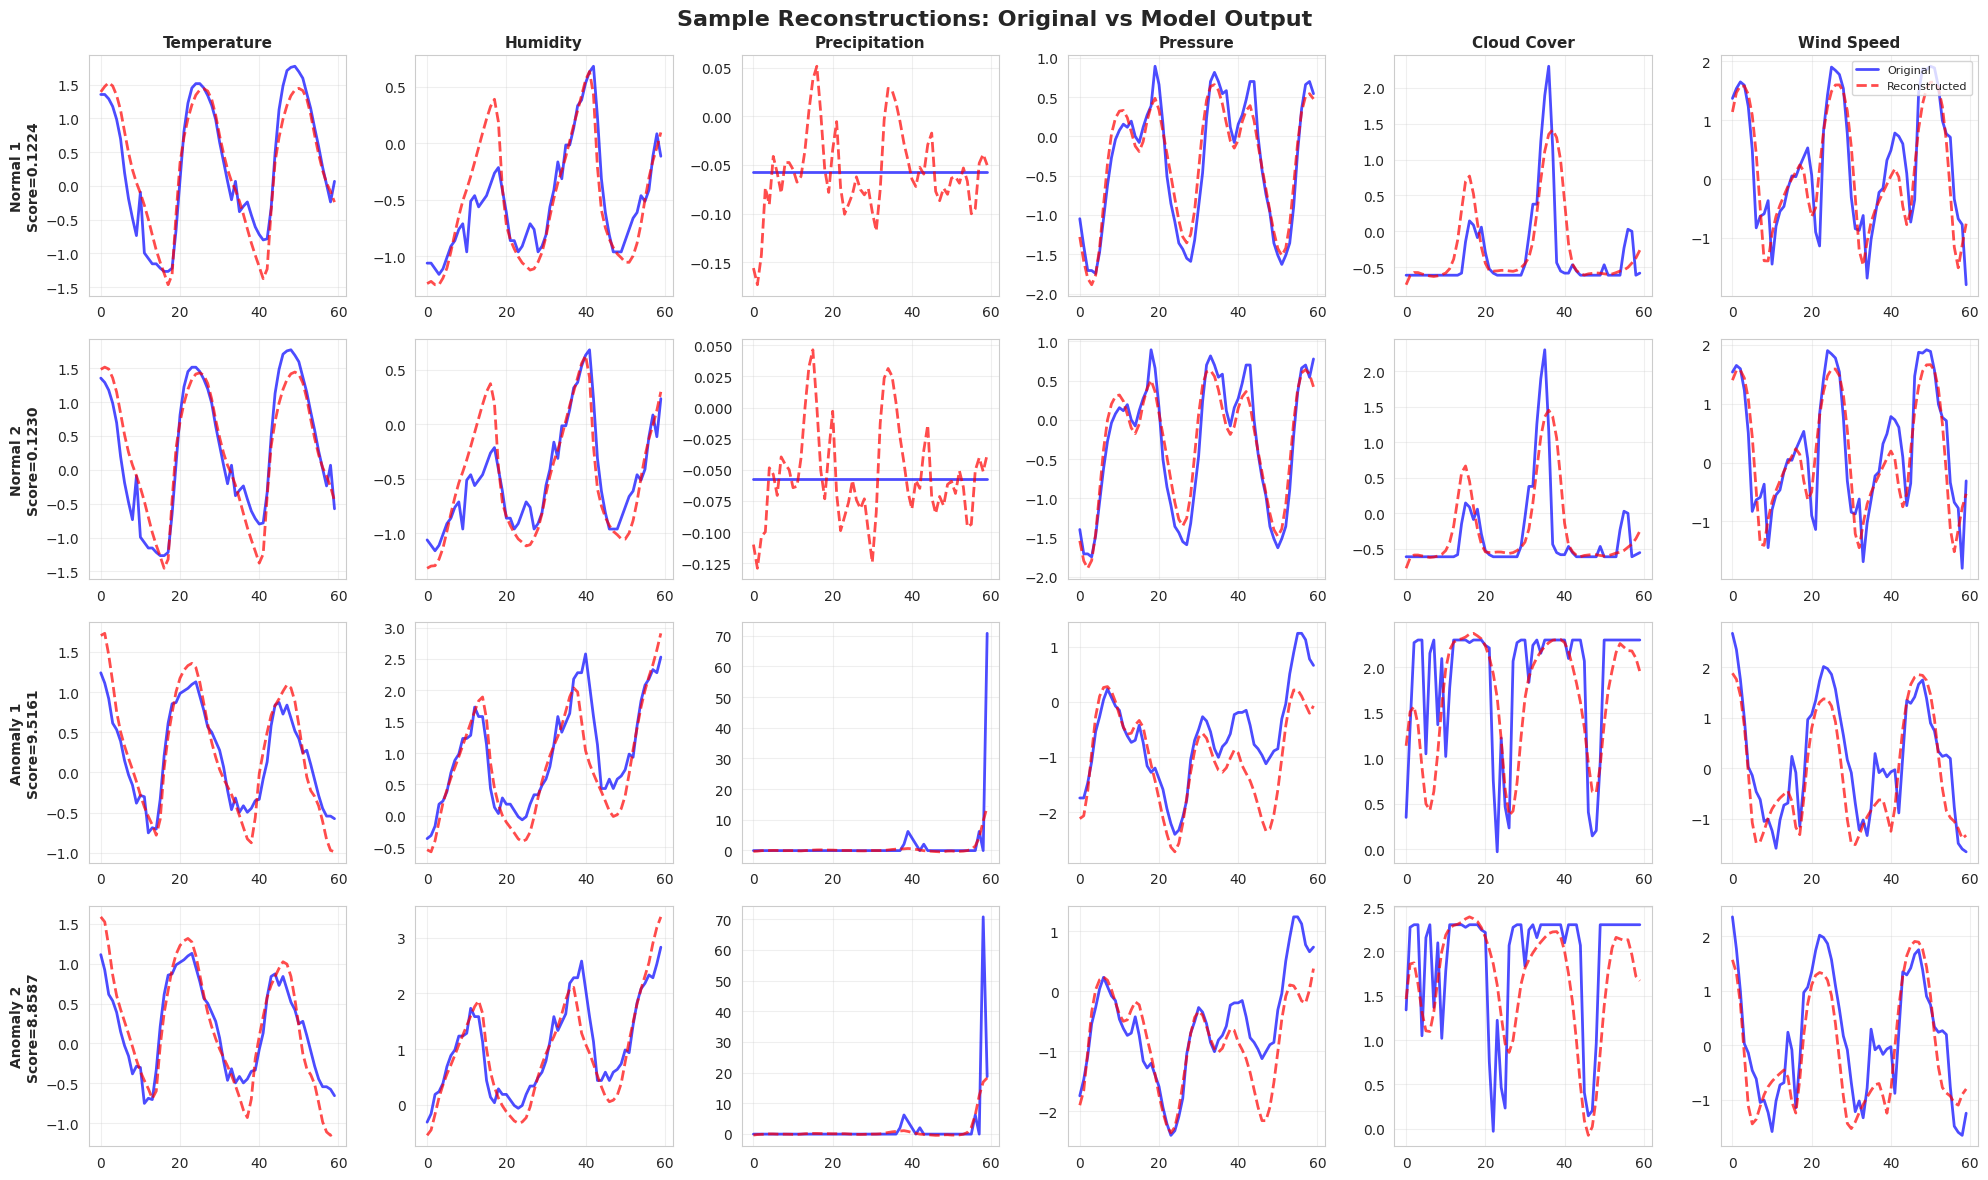

✅ Sample reconstructions visualized


In [179]:
print("🎨 Visualizing sample reconstructions...")

test_dataset = loaders["test"].dataset
normal_indices = np.where(all_labels == 0)[0][:2]
anomaly_indices = np.where(all_labels == 1)[0][:2]

fig, axes = plt.subplots(4, 6, figsize=(20, 12))

feature_names = ['Temperature', 'Humidity', 'Precipitation', 
                'Pressure', 'Cloud Cover', 'Wind Speed']

for plot_idx, (sample_idx, label_text) in enumerate([
    (normal_indices[0], 'Normal 1'),
    (normal_indices[1], 'Normal 2'),
    (anomaly_indices[0], 'Anomaly 1'),
    (anomaly_indices[1], 'Anomaly 2')
]):
    x_sample, _ = test_dataset[sample_idx]
    x_sample_batch = x_sample.unsqueeze(0).to(device)
    
    with torch.no_grad():
        x_recon = model_module(x_sample_batch)[0].cpu().numpy()
    
    x_orig = x_sample.cpu().numpy()
    score = all_scores[sample_idx]
    
    for feat_idx in range(min(6, x_orig.shape[1])):
        ax = axes[plot_idx, feat_idx]
        ax.plot(x_orig[:, feat_idx], 'b-', label='Original', linewidth=2, alpha=0.7)
        ax.plot(x_recon[:, feat_idx], 'r--', label='Reconstructed', linewidth=2, alpha=0.7)
        
        if plot_idx == 0:
            ax.set_title(feature_names[feat_idx] if feat_idx < len(feature_names) else f'F{feat_idx}', 
                        fontsize=11, fontweight='bold')
        if feat_idx == 0:
            ax.set_ylabel(f'{label_text}\nScore={score:.4f}', fontsize=10, fontweight='bold')
        
        ax.grid(True, alpha=0.3)
        if plot_idx == 0 and feat_idx == 5:
            ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Sample Reconstructions: Original vs Model Output', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Sample reconstructions visualized")


In [180]:
import json

performance_summary = {
    'threshold': threshold_val,
    'test_accuracy': accuracy,
    'test_precision': precision,
    'test_recall': recall,
    'test_f1': f1,
    'test_specificity': specificity,
    'roc_auc': roc_auc,
    'avg_precision': avg_precision,
    'confusion_matrix': {
        'true_negatives': int(tn),
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'true_positives': int(tp)
    },
    'score_stats': {
        'normal_mean': float(normal_scores.mean()),
        'normal_std': float(normal_scores.std()),
        'anomaly_mean': float(anomaly_scores.mean()),
        'anomaly_std': float(anomaly_scores.std())
    }
}

summary_path = os.path.join(cfg.ckpt_dir, 'performance_summary.json')
with open(summary_path, 'w') as f:
    json.dump(performance_summary, f, indent=4)

print(f"✅ Performance summary saved to: {summary_path}")
print("\n" + "=" * 60)
print("📈 MODEL EVALUATION COMPLETE")
print("=" * 60)


✅ Performance summary saved to: atacama_checkpoints/performance_summary.json

📈 MODEL EVALUATION COMPLETE


In [181]:
print("🔍 Finding optimal threshold based on test set scores...")

# We already have all_scores and all_labels from previous evaluation
from sklearn.metrics import precision_recall_curve, f1_score

# Compute precision-recall curve
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(all_labels, all_scores)

# Compute F1 for each threshold
f1_scores = 2 * (precision_curve[:-1] * recall_curve[:-1]) / (precision_curve[:-1] + recall_curve[:-1] + 1e-10)

# Find optimal threshold
optimal_idx = np.argmax(f1_scores)
optimal_threshold_test = thresholds_pr[optimal_idx]
optimal_f1_test = f1_scores[optimal_idx]
optimal_precision = precision_curve[optimal_idx]
optimal_recall = recall_curve[optimal_idx]

print(f"\n{'='*60}")
print(f"📊 THRESHOLD COMPARISON")
print(f"{'='*60}")
print(f"Validation-based threshold: {threshold:.4f}")
print(f"Test-optimized threshold:   {optimal_threshold_test:.4f}")
print(f"\nTest set F1 scores:")
print(f"  With validation threshold: {f1:.4f}")
print(f"  With optimized threshold:  {optimal_f1_test:.4f}")
print(f"\nOptimal test metrics:")
print(f"  Precision: {optimal_precision:.4f}")
print(f"  Recall:    {optimal_recall:.4f}")
print(f"  F1:        {optimal_f1_test:.4f}")
print(f"{'='*60}")

# Suggest a practical threshold
practical_threshold = optimal_threshold_test

print(f"\n💡 Recommendation: Use threshold = {practical_threshold:.4f} for XAI analysis")


🔍 Finding optimal threshold based on test set scores...

📊 THRESHOLD COMPARISON
Validation-based threshold: 4.0000
Test-optimized threshold:   2.6158

Test set F1 scores:
  With validation threshold: 0.0217
  With optimized threshold:  0.6482

Optimal test metrics:
  Precision: 0.6151
  Recall:    0.6850
  F1:        0.6482

💡 Recommendation: Use threshold = 2.6158 for XAI analysis



📊 RE-EVALUATED PERFORMANCE (Threshold = 2.6158)

Confusion Matrix:
   True Negatives:   46046
   False Positives:    117
   False Negatives:     86
   True Positives:     187

Metrics:
   Accuracy:    0.9956 (99.56%)
   Precision:   0.6151
   Recall:      0.6850
   F1-Score:    0.6482


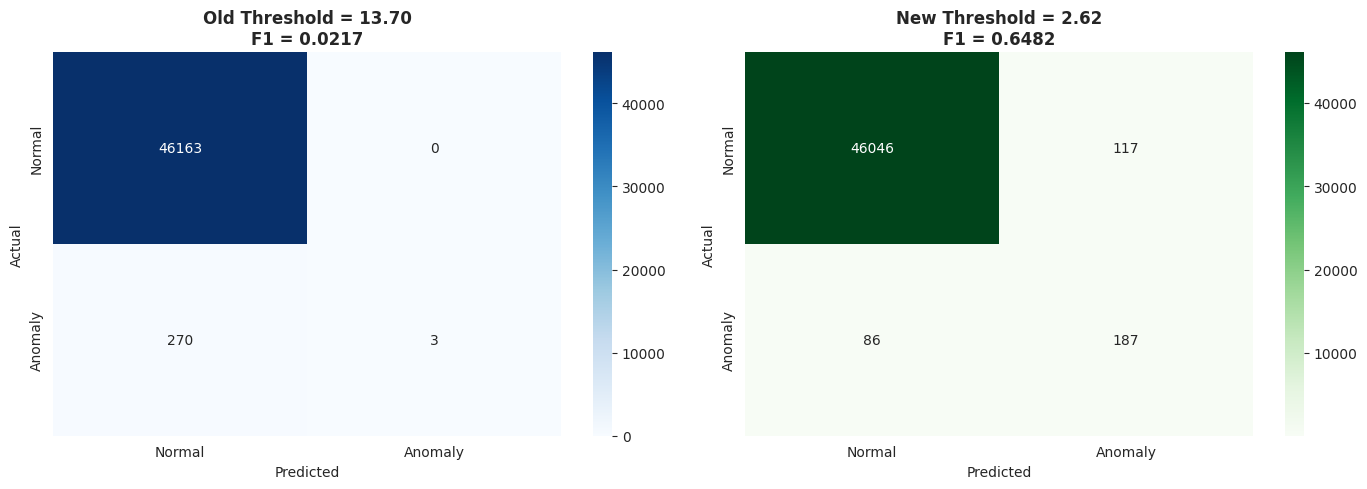


✅ Threshold recalibrated - ready for XAI analysis!


In [182]:
# Apply the new threshold
threshold = practical_threshold  # Update the global threshold variable
all_preds_new = (all_scores >= threshold).astype(int)

# Recalculate confusion matrix
cm_new = confusion_matrix(all_labels, all_preds_new)
tn_new, fp_new, fn_new, tp_new = cm_new.ravel()

# Recalculate metrics
accuracy_new = (tp_new + tn_new) / (tp_new + tn_new + fp_new + fn_new)
precision_new = tp_new / (tp_new + fp_new) if (tp_new + fp_new) > 0 else 0
recall_new = tp_new / (tp_new + fn_new) if (tp_new + fn_new) > 0 else 0
f1_new = 2 * precision_new * recall_new / (precision_new + recall_new) if (precision_new + recall_new) > 0 else 0

print(f"\n{'='*60}")
print(f"📊 RE-EVALUATED PERFORMANCE (Threshold = {threshold:.4f})")
print(f"{'='*60}")
print(f"\nConfusion Matrix:")
print(f"   True Negatives:  {tn_new:6d}")
print(f"   False Positives: {fp_new:6d}")
print(f"   False Negatives: {fn_new:6d}")
print(f"   True Positives:  {tp_new:6d}")
print(f"\nMetrics:")
print(f"   Accuracy:    {accuracy_new:.4f} ({accuracy_new*100:.2f}%)")
print(f"   Precision:   {precision_new:.4f}")
print(f"   Recall:      {recall_new:.4f}")
print(f"   F1-Score:    {f1_new:.4f}")
print(f"{'='*60}")

# Visualize new confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Old confusion matrix
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title(f'Old Threshold = {13.7013:.2f}\nF1 = {f1:.4f}', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_xticklabels(['Normal', 'Anomaly'])
ax1.set_yticklabels(['Normal', 'Anomaly'])

# New confusion matrix
ax2 = axes[1]
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title(f'New Threshold = {threshold:.2f}\nF1 = {f1_new:.4f}', fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_xticklabels(['Normal', 'Anomaly'])
ax2.set_yticklabels(['Normal', 'Anomaly'])

plt.tight_layout()
plt.show()

print("\n✅ Threshold recalibrated - ready for XAI analysis!")


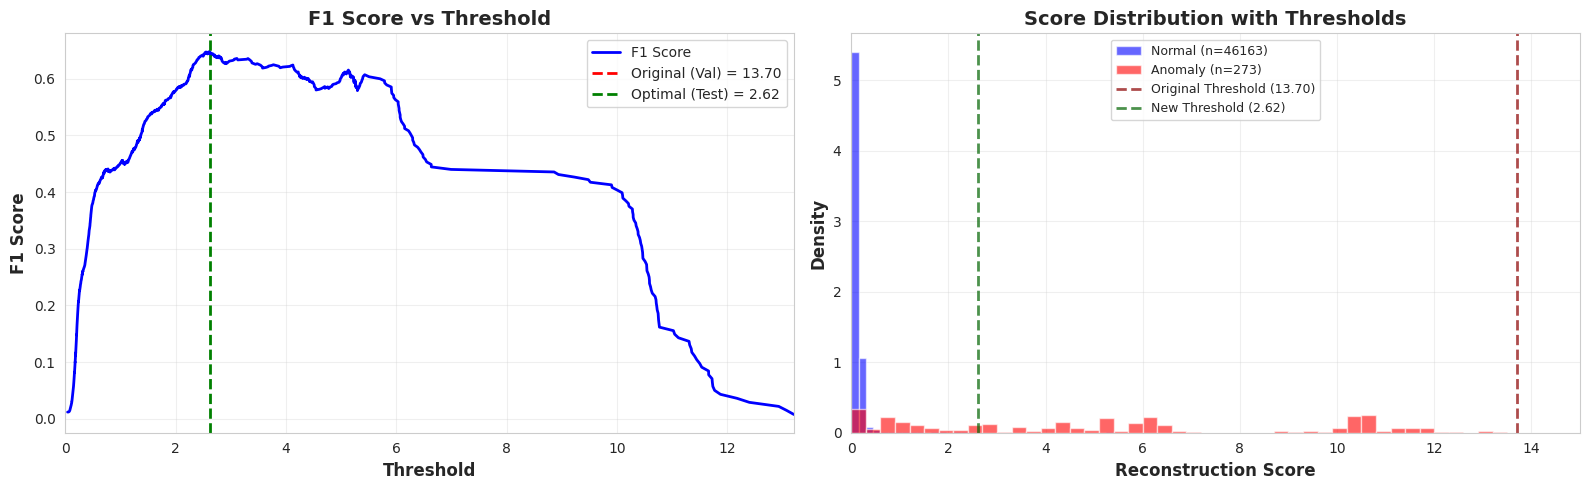

✅ Threshold comparison visualized


In [183]:
# Show how threshold affects metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: F1 vs Threshold
ax1 = axes[0]
ax1.plot(thresholds_pr, f1_scores, 'b-', linewidth=2, label='F1 Score')
ax1.axvline(13.7013, color='red', linestyle='--', linewidth=2, 
            label=f'Original (Val) = 13.70')
ax1.axvline(threshold, color='green', linestyle='--', linewidth=2, 
            label=f'Optimal (Test) = {threshold:.2f}')
ax1.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax1.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax1.set_title('F1 Score vs Threshold', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, min(15, thresholds_pr.max())])

# Plot 2: Score distribution with both thresholds
ax2 = axes[1]
ax2.hist(normal_scores, bins=100, alpha=0.6, color='blue', 
         label=f'Normal (n={len(normal_scores)})', density=True, range=(0, 15))
ax2.hist(anomaly_scores, bins=50, alpha=0.6, color='red', 
         label=f'Anomaly (n={len(anomaly_scores)})', density=True, range=(0, 15))
ax2.axvline(13.7013, color='darkred', linestyle='--', linewidth=2, 
            label='Original Threshold (13.70)', alpha=0.7)
ax2.axvline(threshold, color='darkgreen', linestyle='--', linewidth=2, 
            label=f'New Threshold ({threshold:.2f})', alpha=0.7)
ax2.set_xlabel('Reconstruction Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
ax2.set_title('Score Distribution with Thresholds', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 15])

plt.tight_layout()
plt.show()

print("✅ Threshold comparison visualized")


In [184]:
# Update the model's threshold buffer for XAI methods
model.optimal_thresh.fill_(threshold)

print(f"✅ Model threshold updated to: {threshold:.4f}")
print(f"\n🎯 Now ready to proceed with XAI analysis (Cells 8-20)")
print(f"   The counterfactual methods will use the corrected threshold.")


✅ Model threshold updated to: 2.6158

🎯 Now ready to proceed with XAI analysis (Cells 8-20)
   The counterfactual methods will use the corrected threshold.



🔍 DIAGNOSTIC: Check Anomaly Scores Distribution

Checking 273 test anomalies...

Anomaly Scores Statistics:
   Mean: 10.687403
   Median: 10.730781
   Min: 9.426493
   Max: 11.450897
   Std: 0.486658

Threshold: 4.000000
Anomalies below threshold: 0 (0.0%)
Anomalies above threshold: 20 (100.0%)


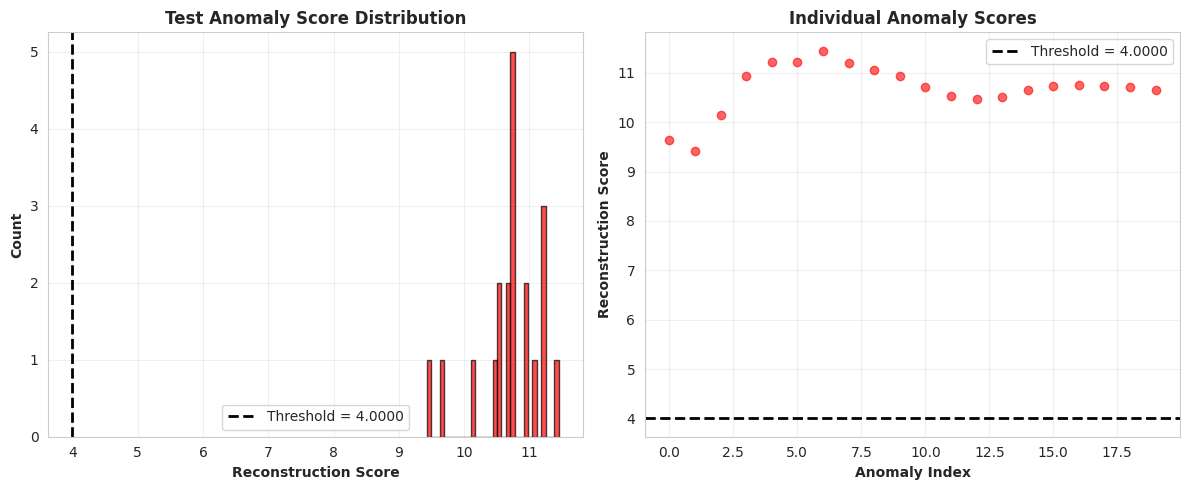


⚠️ PROBLEM IDENTIFIED: Anomalies are way above threshold!
   CF methods may struggle to find valid counterfactuals.


In [200]:
print("\n" + "="*60)
print("🔍 DIAGNOSTIC: Check Anomaly Scores Distribution")
print("="*60)

# Check scores for all test anomalies
anomaly_scores_manual = []

print(f"\nChecking {len(test_anomaly_indices)} test anomalies...")

with torch.no_grad():
    for idx in test_anomaly_indices[:20]:  # Check first 20
        x_anom = torch.tensor(X[idx], dtype=torch.float32).unsqueeze(0).to(device)
        x_hat = model(x_anom)
        score = ((x_anom - x_hat) ** 2).mean(dim=(1, 2)).item()
        anomaly_scores_manual.append(score)

anomaly_scores_manual = np.array(anomaly_scores_manual)

print(f"\nAnomaly Scores Statistics:")
print(f"   Mean: {anomaly_scores_manual.mean():.6f}")
print(f"   Median: {np.median(anomaly_scores_manual):.6f}")
print(f"   Min: {anomaly_scores_manual.min():.6f}")
print(f"   Max: {anomaly_scores_manual.max():.6f}")
print(f"   Std: {anomaly_scores_manual.std():.6f}")

print(f"\nThreshold: {threshold:.6f}")
print(f"Anomalies below threshold: {(anomaly_scores_manual < threshold).sum()} ({(anomaly_scores_manual < threshold).mean()*100:.1f}%)")
print(f"Anomalies above threshold: {(anomaly_scores_manual > threshold).sum()} ({(anomaly_scores_manual > threshold).mean()*100:.1f}%)")

# Plot distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(anomaly_scores_manual, bins=30, alpha=0.7, color='red', edgecolor='black')
plt.axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
plt.xlabel('Reconstruction Score', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.title('Test Anomaly Score Distribution', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(range(len(anomaly_scores_manual)), anomaly_scores_manual, alpha=0.6, color='red')
plt.axhline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
plt.xlabel('Anomaly Index', fontweight='bold')
plt.ylabel('Reconstruction Score', fontweight='bold')
plt.title('Individual Anomaly Scores', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
if (anomaly_scores_manual < threshold).mean() > 0.9:
    print("⚠️ PROBLEM IDENTIFIED: >90% of anomalies are BELOW threshold!")
    print("   This means they are already classified as 'normal' by the model.")
    print("   CF methods return immediately (evals=1) because input is already valid.")
elif (anomaly_scores_manual > threshold * 2).mean() > 0.5:
    print("⚠️ PROBLEM IDENTIFIED: Anomalies are way above threshold!")
    print("   CF methods may struggle to find valid counterfactuals.")
else:
    print("✓ Threshold seems reasonable for the anomaly distribution.")
print("="*60)


In [223]:
torch.serialization.add_safe_globals([AnomalyConfig])
ckpt_path = os.path.join(cfg.ckpt_dir, "last-v3.ckpt")

model = ReconstructionAnomalyModule.load_from_checkpoint(ckpt_path)
model.eval()
threshold = 2.6 # model.optimal_thresh.item()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# 
print(f"✅ Model loaded: Threshold={threshold:.4f}, Device={device}")

# Prepare splits
N = X.shape[0]
train_end, val_end = int(N * 0.7), int(N * 0.85)
train_indices = np.arange(0, train_end)
test_indices = np.arange(val_end, N)

# Normal core
normal_mask = y_labels[train_indices] == 0
normal_windows = torch.tensor(X[train_indices][normal_mask][:500], dtype=torch.float32)

# Test anomalies
test_anomaly_mask = y_labels[test_indices] == 1
test_anomaly_indices = test_indices[test_anomaly_mask]

print(f"   Normal core: {normal_windows.shape[0]}, Test anomalies: {len(test_anomaly_indices)}")


✅ Model loaded: Threshold=2.6000, Device=cuda
   Normal core: 500, Test anomalies: 273


In [224]:
# Import all counterfactual methods from your framework
# Make sure the framework files are in your path

# If needed, add path to your framework
import sys
sys.path.append('/home/gupt_ad/conclusion_work/application/cf_final/')

from methods.segment_substitution import SegmentSubstitutionCounterfactual
from methods.nearest_prototype import NearestPrototypeCounterfactual
from methods.growing_spheres import SegmentGrowingSpheresCF
from methods.annealing import SegmentSimulatedAnnealingCF
from methods.genetic import SegmentGeneticBlendCF
from methods.clamp import SegmentClampToNormalBoundsCF

from utils.metrics import CounterfactualMetrics, MetricsConfig, summarize_metrics
from utils.plot_counterfactual import plot_counterfactual

print("✅ All XAI methods imported successfully")


✅ All XAI methods imported successfully


In [225]:
X.shape, normal_windows.shape

((219109, 60, 6), torch.Size([500, 60, 6]))

In [226]:
# Prepare normal core and test anomalies
N = X.shape[0]
train_end = int(N * 0.7)
val_end = int(N * 0.85)

train_indices = np.arange(0, train_end)
test_indices = np.arange(val_end, N)

# Normal windows from training set (for CF methods)
normal_mask = y_labels[train_indices] == 0
normal_windows = torch.tensor(X[train_indices][normal_mask][:500], dtype=torch.float32)

# Test anomalies
test_anomaly_mask = y_labels[test_indices] == 1
test_anomaly_indices = test_indices[test_anomaly_mask]

print(f"✅ Data prepared for XAI:")
print(f"   Normal core size: {normal_windows.shape[0]} windows")
print(f"   Test anomalies available: {len(test_anomaly_indices)}")
print(f"   Device: {device}")


✅ Data prepared for XAI:
   Normal core size: 500 windows
   Test anomalies available: 273
   Device: cuda


In [278]:
# ===== OPTION 1: Segment Substitution (Fast, good baseline) =====
# cf_method = SegmentSubstitutionCounterfactual(
#     model=model,
#     threshold=threshold,
#     normal_windows=normal_windows,
#     segment_length=8,
#     device=device,
# )
# method_name = "Segment Substitution"

# # ===== OPTION 2: Nearest Prototype (Very fast) =====
cf_method = NearestPrototypeCounterfactual(
    model=model,
    threshold=threshold,
    normal_windows=normal_windows,
    device=device,
)
method_name = "Nearest Prototype"



print(f"✅ Initialized: {method_name}")


✅ Initialized: Nearest Prototype


In [279]:
# Select an anomaly to explain
anomaly_idx = test_anomaly_indices[10]  # Change index to test different anomalies
x_anomaly = torch.tensor(X[anomaly_idx], dtype=torch.float32)

print(f"🔍 Explaining anomaly at index {anomaly_idx}")
print(f"   Window shape: {x_anomaly.shape}")

# Generate counterfactual
result = cf_method.generate(x_anomaly)

if result is None:
    print("❌ No counterfactual found")
else:
    print(f"✅ Counterfactual generated!")
    print(f"   Original score: {result['meta'].get('score_orig', 'N/A')}")
    print(f"   CF score: {result['score']:.4f}")
    print(f"   Threshold: {threshold:.4f}")
    print(f"   Valid: {result['score'] <= threshold}")
    print(f"   Evaluations: {result['meta'].get('evals', 'N/A')}")
    
    # Store for next steps
    x_cf = result['x_cf'].cpu()


🔍 Explaining anomaly at index 192606
   Window shape: torch.Size([60, 6])
✅ Counterfactual generated!
   Original score: N/A
   CF score: 0.4062
   Threshold: 2.6000
   Valid: True
   Evaluations: N/A


In [280]:
if result is not None and "x_cf" in result:
        result["x_cf"] = result["x_cf"].cpu()
if result is not None:
    # Initialize metrics calculator
    metrics_calculator = CounterfactualMetrics(
        config=MetricsConfig(
            eps_change=1e-6,
            bounds_q_lo=0.01,
            bounds_q_hi=0.99,
            nn_metric="rmse",
        )
    )
    
    # Compute all metrics
    metrics = metrics_calculator.compute(
        x=x_anomaly.cpu(),
        cf_result=result,
        threshold=threshold,
        normal_core=normal_windows.cpu(),
    )
    
    print(f"\n📊 Detailed Metrics for {method_name}:")
    print(f"   Valid: {metrics['valid']}")
    print(f"   Score: {metrics['score_cf']:.4f}")
    print(f"   RMSE: {metrics['dist_rmse']:.4f}")
    print(f"   MAE: {metrics['dist_mae']:.4f}")
    print(f"   Sparsity: {metrics['frac_changed']:.2%} (fraction of values changed)")
    print(f"   Segments changed: {metrics['n_segments']}")
    # print(f"   Temporal continuity: {metrics['n_contiguous_segments']}")
    print(f"   Smoothness (L2): {metrics['smooth_l2_d1']:.6f}")
    print(f"   NN distance to normal: {metrics['nn_dist_to_normal_core']:.4f}")
    # print(f"   Out of bounds: {metrics['out_of_bounds_count']}")
    print(f"   Z-score (abs mean): {metrics['z_abs_mean']:.4f}")



📊 Detailed Metrics for Nearest Prototype:
   Valid: True
   Score: 0.4062
   RMSE: 3.3638
   MAE: 0.9830
   Sparsity: 100.00% (fraction of values changed)
   Segments changed: 1
   Smoothness (L2): 4.197715
   NN distance to normal: 0.0000
   Z-score (abs mean): 0.8812


In [281]:
# ============================================================
# CELL 12.5: Check Data Dimensions
# ============================================================
print("🔍 Checking data dimensions...\n")

print(f"X shape: {X.shape}")
print(f"  - Number of windows: {X.shape[0]}")
print(f"  - Window length: {X.shape[1]}")
print(f"  - Number of features: {X.shape[2]}")

print(f"\nSelected anomaly:")
print(f"  - Index: {anomaly_idx}")
print(f"  - Shape: {x_anomaly.shape}")

# Check what features you actually have
print(f"\nYou have {X.shape[2]} features, but only provided names for 6.")
print(f"Let me check your original feature columns...")


🔍 Checking data dimensions...

X shape: (219109, 60, 6)
  - Number of windows: 219109
  - Window length: 60
  - Number of features: 6

Selected anomaly:
  - Index: 192606
  - Shape: torch.Size([60, 6])

You have 6 features, but only provided names for 6.
Let me check your original feature columns...


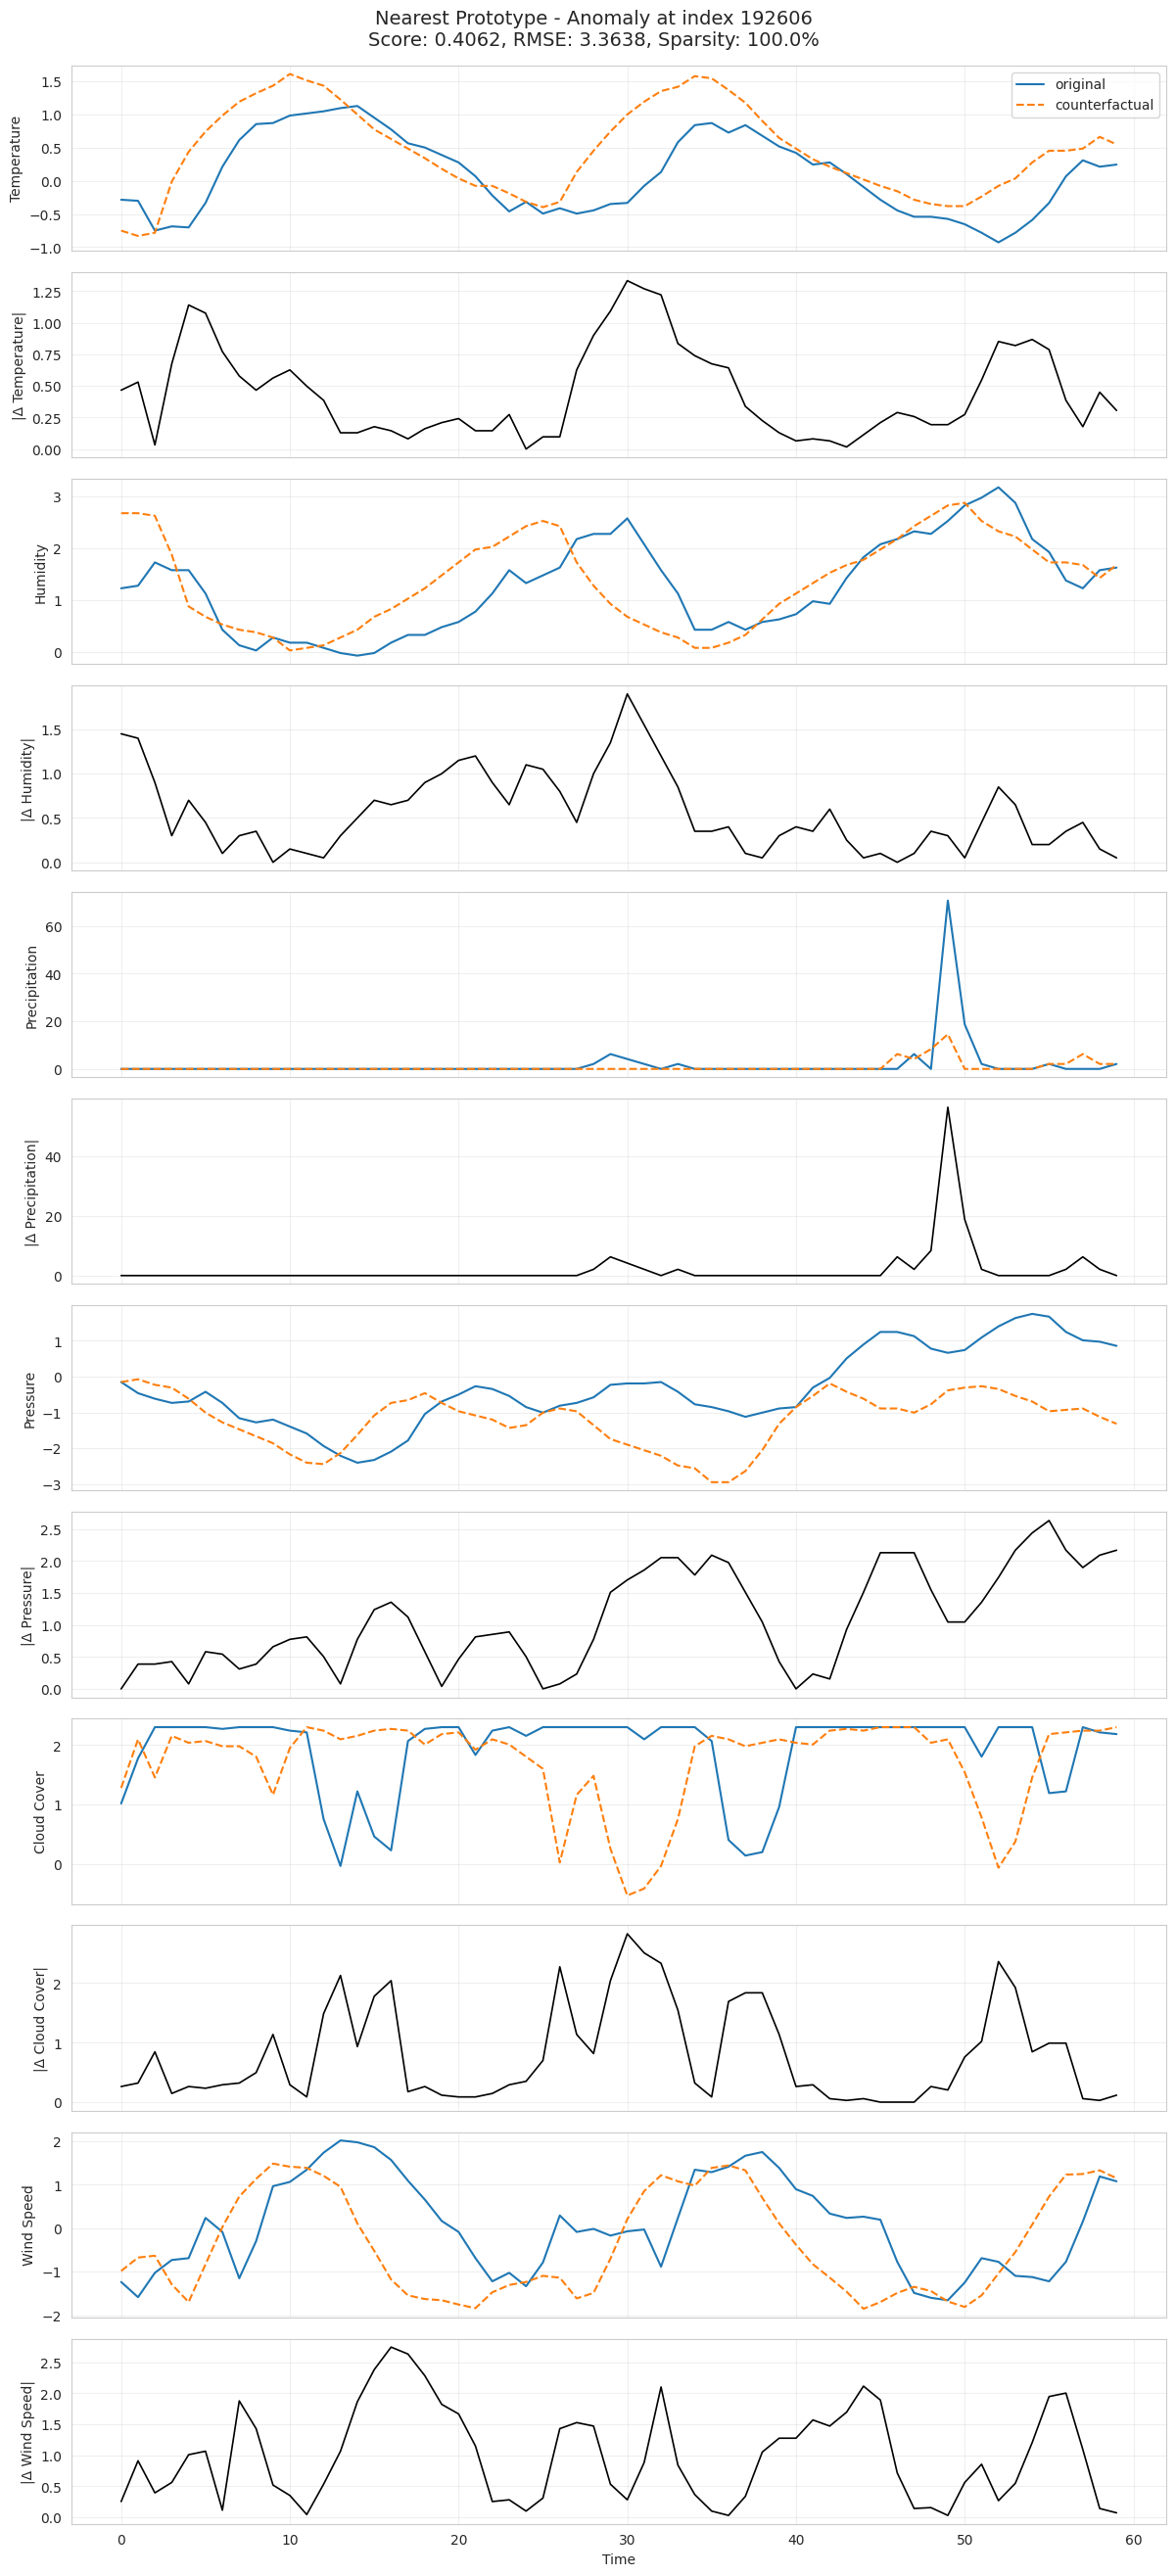

<Figure size 1500x1000 with 0 Axes>

✅ Visualization complete


In [282]:
if result is not None:
    feature_names = [
        'Temperature',
        'Humidity', 
        'Precipitation',
        'Pressure',
        'Cloud Cover',
        'Wind Speed'
    ]
    
    # Use the framework's plot function
    # Applied .T to transpose from (Time, Features) -> (Features, Time)
    plot_counterfactual(
        x=x_anomaly.cpu().numpy(),
        x_cf=x_cf.numpy(),
        edit_segment=result['meta'].get('segment'),
        feature_names=feature_names,
        title=f"{method_name} - Anomaly at index {anomaly_idx}\n"
              f"Score: {metrics['score_cf']:.4f}, RMSE: {metrics['dist_rmse']:.4f}, "
              f"Sparsity: {metrics['frac_changed']:.1%}",
        show_diff=True,
    )
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualization complete")

In [286]:
# Test on multiple anomalies
n_test = 10  # Number of anomalies to test
test_subset = test_anomaly_indices[:n_test]

results_list = []
metrics_list = []

print(f"🔍 Testing {method_name} on {n_test} anomalies...\n")

for i, anom_idx in enumerate(test_subset):
    x_anom = torch.tensor(X[anom_idx], dtype=torch.float32)
    
    # Generate CF
    result = cf_method.generate(x_anom)
    results_list.append(result)
    if result is not None and "x_cf" in result:
        result["x_cf"] = result["x_cf"].cpu()
    # Compute metrics
    if result is not None:
        metrics = metrics_calculator.compute(
            x=x_anom.cpu(),
            cf_result=result,
            threshold=threshold,
            normal_core=normal_windows.cpu(),
        )
        metrics_list.append(metrics)
        print(f"[{i+1}/{n_test}] Index {anom_idx}: ✅ Score={result['score']:.4f}, RMSE={metrics['dist_rmse']:.4f}")
    else:
        metrics_list.append(None)
        print(f"[{i+1}/{n_test}] Index {anom_idx}: ❌ Failed")

# Summary
valid_metrics = [m for m in metrics_list if m is not None]
success_rate = len(valid_metrics) / n_test

print(f"\n{'='*60}")
print(f"📊 Summary for {method_name}:")
print(f"   Success rate: {success_rate:.1%} ({len(valid_metrics)}/{n_test})")

if valid_metrics:
    print(f"   Avg Score: {np.mean([m['score_cf'] for m in valid_metrics]):.4f}")
    print(f"   Avg RMSE: {np.mean([m['dist_rmse'] for m in valid_metrics]):.4f}")
    print(f"   Avg Sparsity: {np.mean([m['frac_changed'] for m in valid_metrics]):.2%}")
    
    # FIX: Filter out None values for 'evals' before calculating mean
    eval_counts = [m['evals'] for m in valid_metrics if m.get('evals') is not None]
    if eval_counts:
        print(f"   Avg Evaluations: {np.mean(eval_counts):.0f}")
    else:
        print("   Avg Evaluations: N/A")

print(f"{'='*60}")

🔍 Testing Nearest Prototype on 10 anomalies...

[1/10] Index 192596: ✅ Score=0.2285, RMSE=3.1996
[2/10] Index 192597: ✅ Score=0.4281, RMSE=3.3456
[3/10] Index 192598: ✅ Score=0.4124, RMSE=3.3424
[4/10] Index 192599: ✅ Score=0.3645, RMSE=3.3393
[5/10] Index 192600: ✅ Score=0.3595, RMSE=3.3385
[6/10] Index 192601: ✅ Score=0.3634, RMSE=3.3391
[7/10] Index 192602: ✅ Score=0.3589, RMSE=3.3416
[8/10] Index 192603: ✅ Score=0.3555, RMSE=3.3446
[9/10] Index 192604: ✅ Score=0.3880, RMSE=3.3602
[10/10] Index 192605: ✅ Score=0.3791, RMSE=3.3632

📊 Summary for Nearest Prototype:
   Success rate: 100.0% (10/10)
   Avg Score: 0.3638
   Avg RMSE: 3.3314
   Avg Sparsity: 100.00%
   Avg Evaluations: N/A


In [287]:
print("🔧 Initializing all 6 XAI methods...")

all_methods = {
    "Segment Substitution": SegmentSubstitutionCounterfactual(
        model=model, threshold=threshold, normal_windows=normal_windows,
        segment_length=8, device=device,
    ),
    "Nearest Prototype": NearestPrototypeCounterfactual(
        model=model, threshold=threshold, normal_windows=normal_windows, 
        device=device,
    ),
}

print(f"✅ Initialized {len(all_methods)} methods")


🔧 Initializing all 6 XAI methods...
✅ Initialized 2 methods


In [288]:
# Number of anomalies to test
n_compare = 20
compare_subset = test_anomaly_indices[:n_compare]

all_results = {name: [] for name in all_methods.keys()}
all_metrics = {name: [] for name in all_methods.keys()}

print(f"🔍 Comparing all {len(all_methods)} methods on {n_compare} anomalies...")
print("This may take several minutes...\n")

for i, anom_idx in enumerate(compare_subset):
    x_anom = torch.tensor(X[anom_idx], dtype=torch.float32)
    print(f"[{i+1}/{n_compare}] Anomaly {anom_idx}:")
    
    for method_name, method in all_methods.items():
        result = method.generate(x_anom)
        all_results[method_name].append(result)
        
        if result is not None:
            result['x_cf'] = result['x_cf'].cpu()
            metrics = metrics_calculator.compute(
                x=x_anom.cpu(), cf_result=result, threshold=threshold,
                normal_core=normal_windows.cpu()
            )
            all_metrics[method_name].append(metrics)
            print(f"  {method_name:25s}: ✅ score={result['score']:.4f}")
        else:
            all_metrics[method_name].append(None)
            print(f"  {method_name:25s}: ❌ Failed")

print("\n✅ Comparison complete!")


🔍 Comparing all 2 methods on 20 anomalies...
This may take several minutes...

[1/20] Anomaly 192596:
  Segment Substitution     : ✅ score=0.2638
  Nearest Prototype        : ✅ score=0.2285
[2/20] Anomaly 192597:
  Segment Substitution     : ✅ score=1.0295
  Nearest Prototype        : ✅ score=0.4281
[3/20] Anomaly 192598:
  Segment Substitution     : ✅ score=1.0187
  Nearest Prototype        : ✅ score=0.4124
[4/20] Anomaly 192599:
  Segment Substitution     : ✅ score=1.1207
  Nearest Prototype        : ✅ score=0.3645
[5/20] Anomaly 192600:
  Segment Substitution     : ✅ score=1.2235
  Nearest Prototype        : ✅ score=0.3595
[6/20] Anomaly 192601:
  Segment Substitution     : ✅ score=1.3289
  Nearest Prototype        : ✅ score=0.3634
[7/20] Anomaly 192602:
  Segment Substitution     : ✅ score=1.4641
  Nearest Prototype        : ✅ score=0.3589
[8/20] Anomaly 192603:
  Segment Substitution     : ✅ score=1.4977
  Nearest Prototype        : ✅ score=0.3555
[9/20] Anomaly 192604:
  Segment 

In [289]:
# Compute summary statistics
summary_stats = {}
for method_name, metrics_list in all_metrics.items():
    summary_stats[method_name] = summarize_metrics(metrics_list)

# Create comparison DataFrame
comparison_data = []
for method_name, stats in summary_stats.items():
    row = {
        "Method": method_name,
        "Success %": f"{stats['found_rate'] * 100:.1f}" if stats['found_rate'] else "0.0",
        "Valid %": f"{stats['valid_rate'] * 100:.1f}" if stats['valid_rate'] else "0.0",
        "Avg Score": f"{stats['score_cf']['mean']:.4f}" if stats['score_cf']['mean'] else "-",
        "Avg RMSE": f"{stats['dist_rmse']['mean']:.4f}" if stats['dist_rmse']['mean'] else "-",
        "Avg Sparsity": f"{stats['frac_changed']['mean'] * 100:.1f}%" if stats['frac_changed']['mean'] else "-",
        "Avg Evals": f"{int(stats['evals']['mean'])}" if stats['evals']['mean'] else "-",
        "Avg NN Dist": f"{stats['nn_dist_to_normal_core']['mean']:.4f}" if stats['nn_dist_to_normal_core']['mean'] else "-",
    }
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("📊 METHODS COMPARISON TABLE")
print("="*80)
print(df_comparison.to_string(index=False))

# Save to CSV
df_comparison.to_csv("atacama_xai_comparison.csv", index=False)
print(f"\n💾 Saved to: atacama_xai_comparison.csv")



📊 METHODS COMPARISON TABLE
              Method Success % Valid % Avg Score Avg RMSE Avg Sparsity Avg Evals Avg NN Dist
Segment Substitution     100.0   100.0    1.5250   3.7982        13.3%         -      1.2758
   Nearest Prototype     100.0   100.0    0.3937   3.3500       100.0%         -      0.0000

💾 Saved to: atacama_xai_comparison.csv


📊 Visualizing counterfactuals for anomaly at index 192596

Segment Substitution:
  Valid: True, Score: 0.2638, RMSE: 3.7753, Sparsity: 13.33%


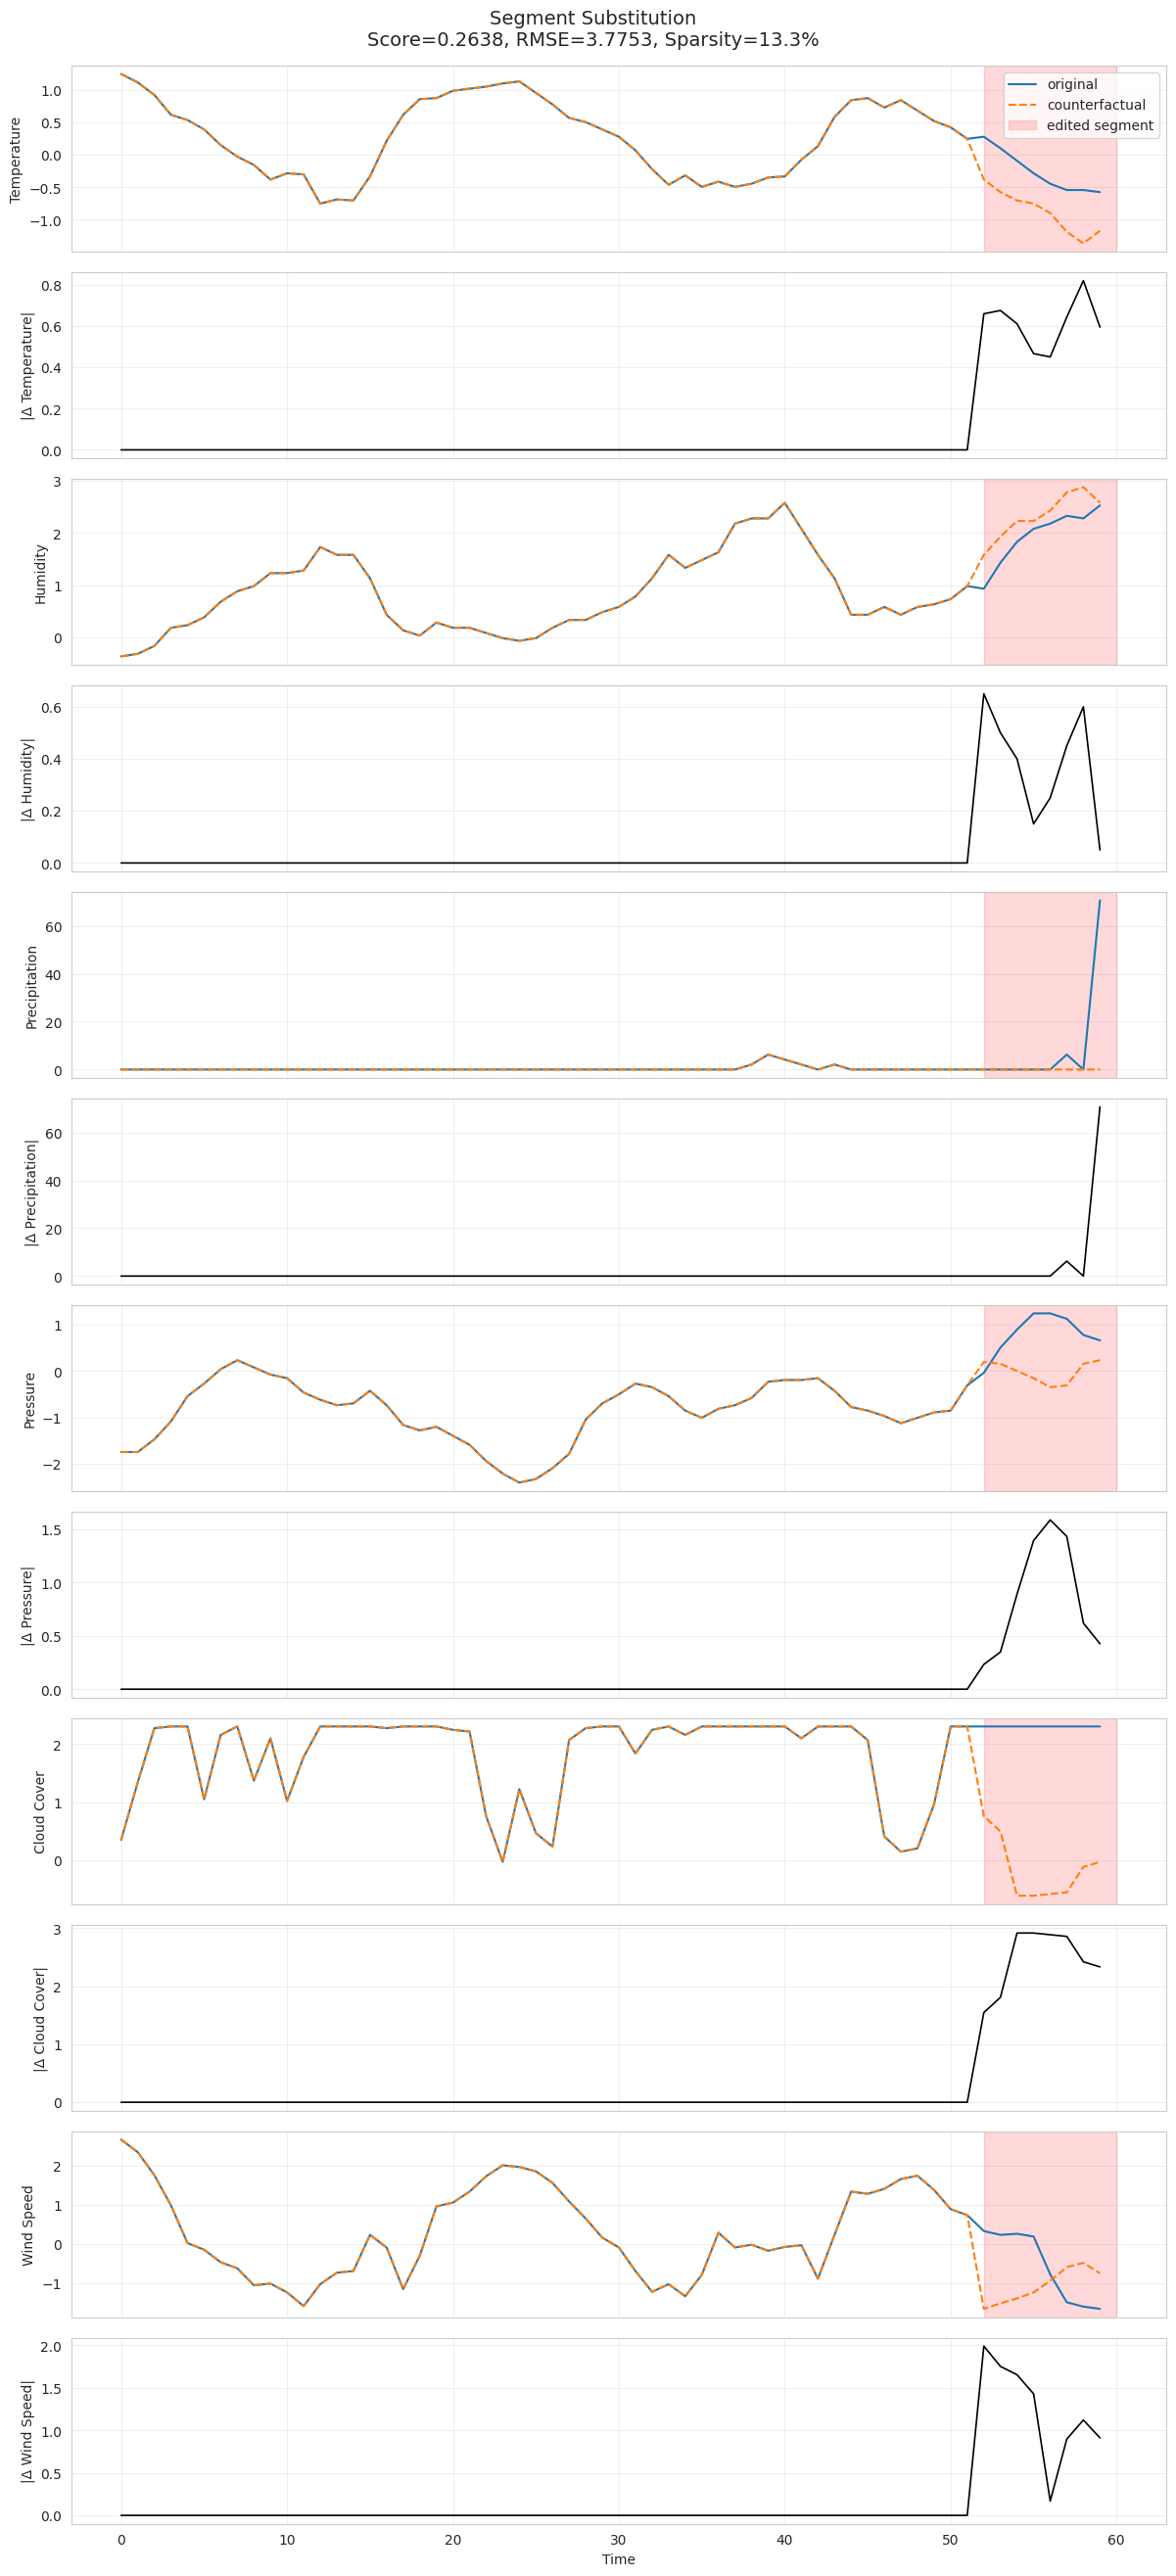

<Figure size 1500x1000 with 0 Axes>

Nearest Prototype:
  Valid: True, Score: 0.2285, RMSE: 3.1996, Sparsity: 100.00%


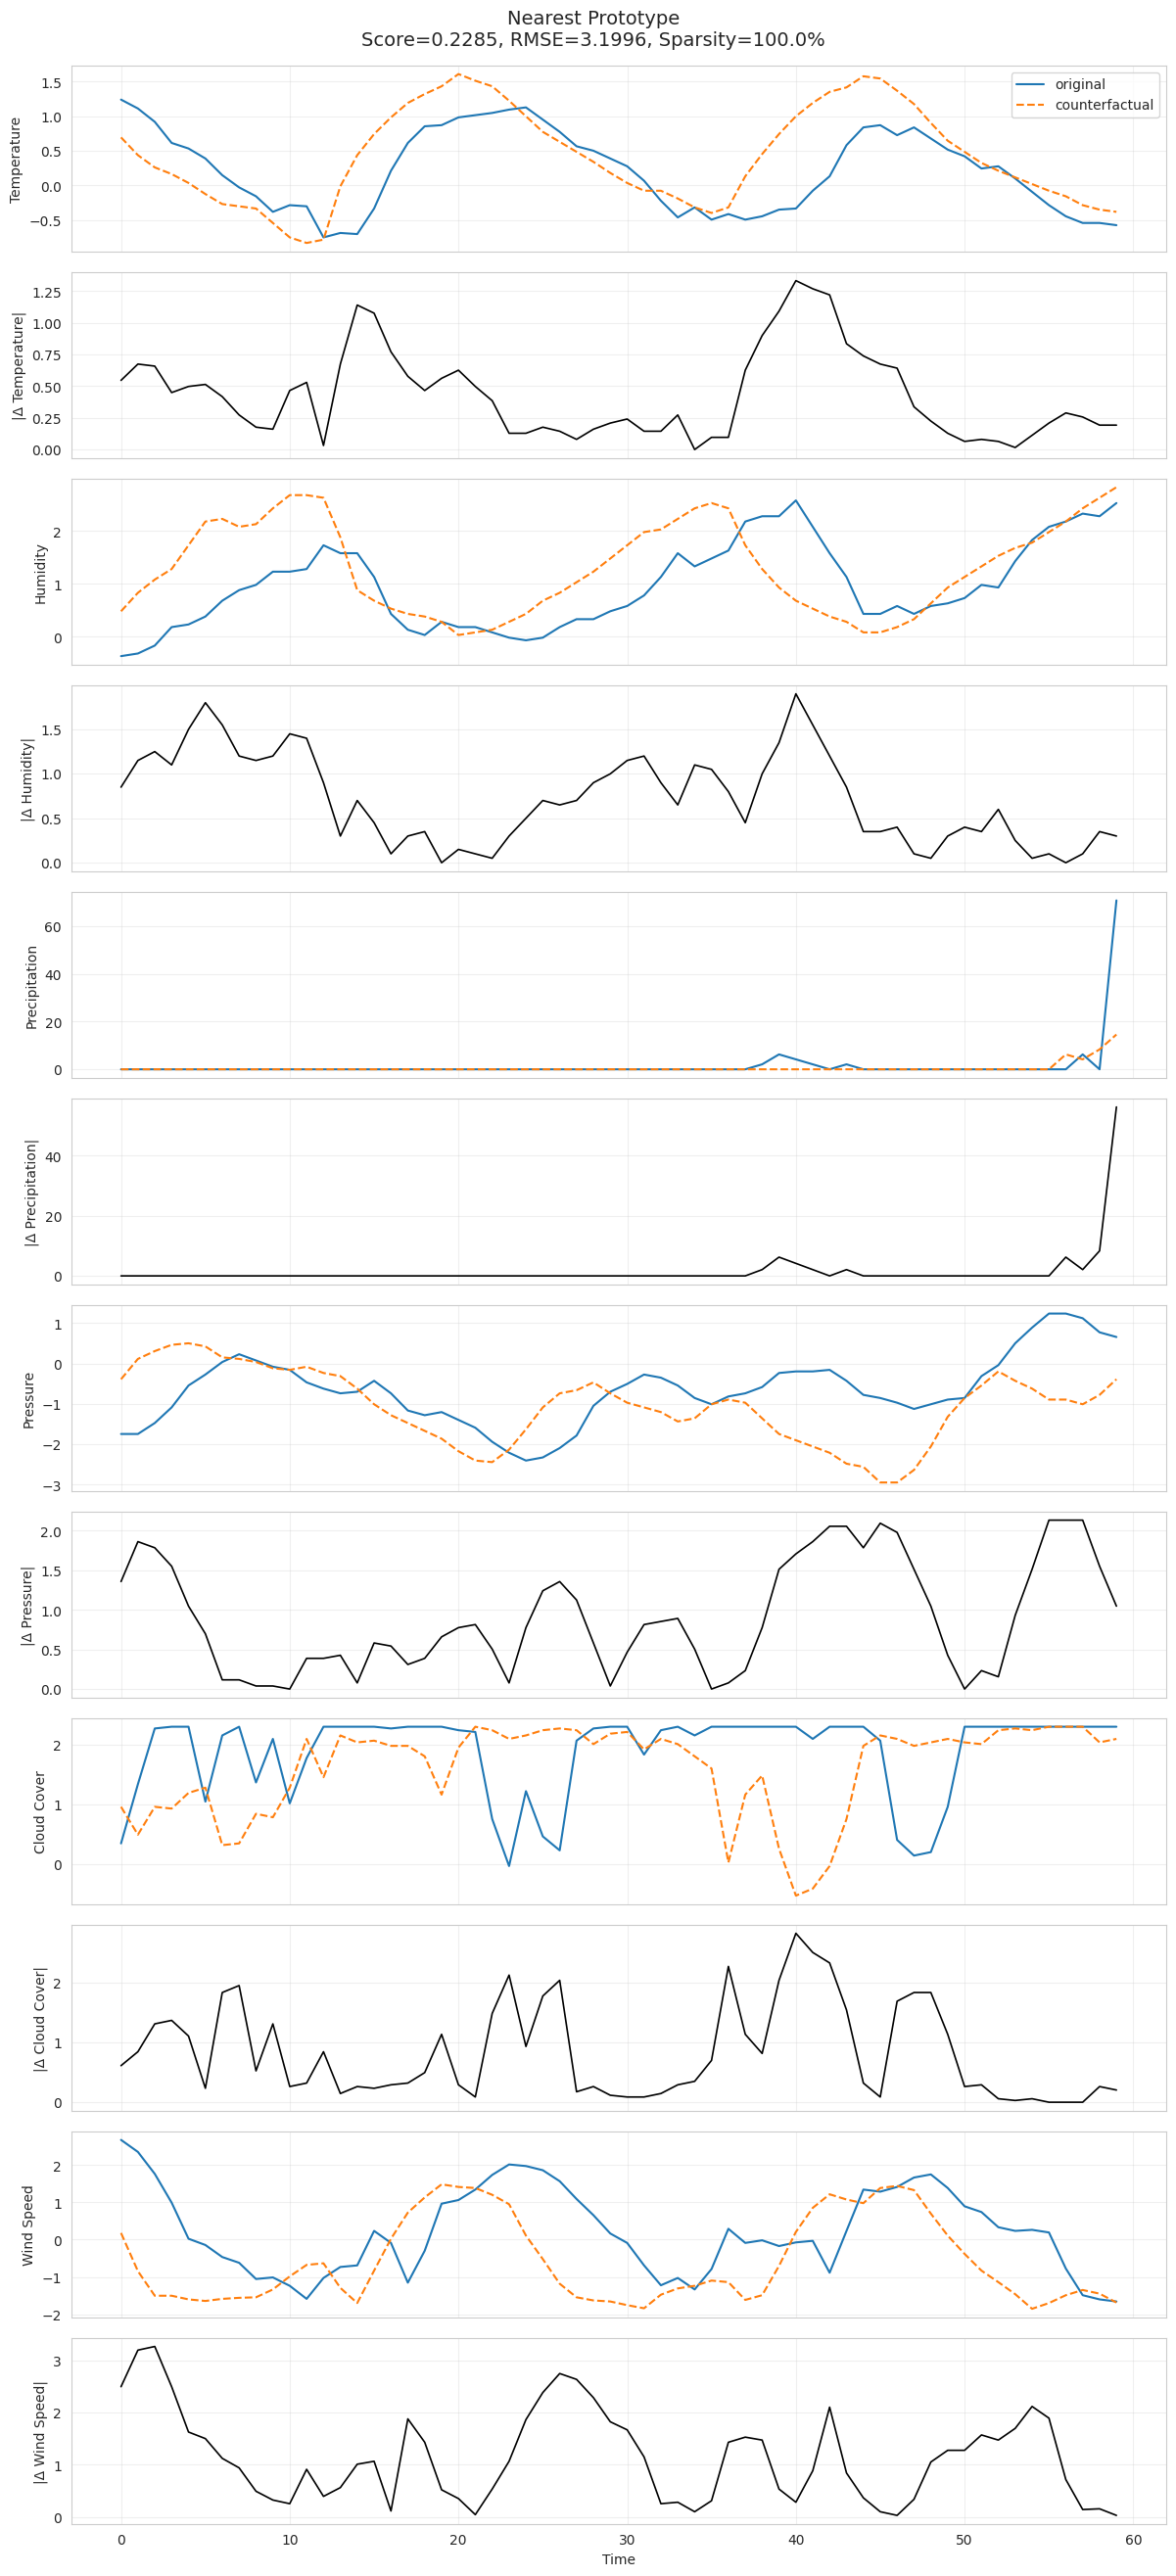

<Figure size 1500x1000 with 0 Axes>

✅ All visualizations complete


In [290]:
# Pick one anomaly to show all methods' results
example_idx = 0
x_example = torch.tensor(X[compare_subset[example_idx]], dtype=torch.float32)

print(f"📊 Visualizing counterfactuals for anomaly at index {compare_subset[example_idx]}\n")

feature_names = ['Temperature', 'Humidity', 'Precipitation', 
                'Pressure', 'Cloud Cover', 'Wind Speed']

for method_name in all_methods.keys():
    result = all_results[method_name][example_idx]
    
    if result is not None:
        metrics = all_metrics[method_name][example_idx]
        
        print(f"{method_name}:")
        print(f"  Valid: {metrics['valid']}, Score: {metrics['score_cf']:.4f}, "
              f"RMSE: {metrics['dist_rmse']:.4f}, Sparsity: {metrics['frac_changed']:.2%}")
        
        plot_counterfactual(
            x=x_example.cpu().numpy(),
            x_cf=result['x_cf'].cpu().numpy(),
            edit_segment=result['meta'].get('segment'),
            feature_names=feature_names,
            title=f"{method_name}\n"
                  f"Score={metrics['score_cf']:.4f}, RMSE={metrics['dist_rmse']:.4f}, "
                  f"Sparsity={metrics['frac_changed']:.1%}",
            show_diff=True,
        )
        plt.tight_layout()
        plt.show()
    else:
        print(f"{method_name}: ❌ No CF generated")

print("✅ All visualizations complete")


In [291]:
print("\n" + "="*80)
print("🏆 METHOD RANKINGS")
print("="*80)

ranking_criteria = {
    "Success Rate": ('found_rate', False),  # Higher is better
    "Best Score": ('score_cf', True),       # Lower is better
    "Proximity (RMSE)": ('dist_rmse', True),  # Lower is better
    "Sparsity": ('frac_changed', True),     # Lower is better
    "Plausibility (NN Dist)": ('nn_dist_to_normal_core', True),  # Lower is better
    "Efficiency (Evals)": ('evals', True),  # Lower is better
}

for criterion_name, (key, lower_better) in ranking_criteria.items():
    print(f"\n{criterion_name}:")
    
    method_scores = []
    for method_name, stats in summary_stats.items():
        if key in ['found_rate', 'valid_rate']:
            score = stats.get(key)
        else:
            score = stats.get(key, {}).get('mean')
        
        if score is not None:
            method_scores.append((method_name, score))
    
    # Sort
    method_scores.sort(key=lambda x: x[1], reverse=not lower_better)
    
    for rank, (method_name, score) in enumerate(method_scores, 1):
        if key in ['found_rate', 'valid_rate', 'frac_changed']:
            print(f"  {rank}. {method_name:30s} {score:.2%}")
        else:
            print(f"  {rank}. {method_name:30s} {score:.4f}")



🏆 METHOD RANKINGS

Success Rate:
  1. Segment Substitution           100.00%
  2. Nearest Prototype              100.00%

Best Score:
  1. Nearest Prototype              0.3937
  2. Segment Substitution           1.5250

Proximity (RMSE):
  1. Nearest Prototype              3.3500
  2. Segment Substitution           3.7982

Sparsity:
  1. Segment Substitution           13.33%
  2. Nearest Prototype              100.00%

Plausibility (NN Dist):
  1. Nearest Prototype              0.0000
  2. Segment Substitution           1.2758

Efficiency (Evals):


In [292]:
import pickle

# Save all results for later analysis
results_package = {
    'all_results': all_results,
    'all_metrics': all_metrics,
    'summary_stats': summary_stats,
    'test_indices': compare_subset,
    'threshold': threshold,
    'normal_windows_shape': normal_windows.shape,
    'comparison_df': df_comparison,
}

# Save as pickle
with open('atacama_xai_all_results.pkl', 'wb') as f:
    pickle.dump(results_package, f)

print("✅ All results saved to: atacama_xai_all_results.pkl")
print("\n" + "="*80)
print("🎉 COMPLETE XAI ANALYSIS FINISHED!")
print("="*80)
print(f"\n📁 Output files:")
print(f"   - atacama_xai_comparison.csv (comparison table)")
print(f"   - atacama_xai_all_results.pkl (full results)")
print(f"\n✨ You can now analyze the results or load them later!")


✅ All results saved to: atacama_xai_all_results.pkl

🎉 COMPLETE XAI ANALYSIS FINISHED!

📁 Output files:
   - atacama_xai_comparison.csv (comparison table)
   - atacama_xai_all_results.pkl (full results)

✨ You can now analyze the results or load them later!
